# 25.43 Laboratorio de Procesamiento de Señales — TP1 Estimación espectral

## GW150914

El 14 de septiembre de 2015, dos agujeros negros que llevaban mil millones de años cayéndose uno
sobre el otro [se fundieron en uno solo](https://youtu.be/Zt8Z_uzG71o?si=gQAwzKlSnAiCpfYi). La onda gravitatoria de esa fusión viajó 1300 millones de
años y atravesó la Tierra en dos décimas de segundo. La midieron dos interferómetros de cuatro
kilómetros de brazo: uno en [Hanford](https://maps.app.goo.gl/SequJrz9X3Jh53wU7) (H1) y otro en [Livingston](https://maps.app.goo.gl/pvzRZ7Ep26RGV241A) (L1), separados por 3002 km.

[Lo que midieron](https://youtu.be/TWqhUANNFXw?si=wPcfMSoKkoL0-YcT) es un estiramiento del espacio de una parte en 10²¹.

| | |
|---|---|
| fecha | 14/09/2015, 09:50:45 UTC |
| detectores | LIGO — Hanford (H1) y Livingston (L1) |
| strain | ~10⁻²¹ |
| banda | 35 a 350 Hz |
| duración | 0,2 s |

**En el registro crudo no se ve nada.** La señal está hundida en el ruido del detector, y ese
ruido es de todo menos blanco. Este TP es el trabajo que hay que hacer para que aparezca — y para
medir, al final, de qué parte del cielo vino.

---

## Qué se entrega

**Esta misma notebook, completada y corrida de arriba abajo.** No hay informe aparte: el
análisis va en las celdas de markdown, debajo de la figura que lo sostiene.

Antes de entregar, *Kernel → Restart & Run All*. Si no corre de punta a punta, no se corrige.

## Cómo se evalúa

| Criterio | Peso |
|---|---|
| **Análisis crítico** | **40 %** |
| Corrección técnica | 30 % |
| Figuras | 15 % |
| Reproducibilidad | 15 % |

**El núcleo son las cinco partes.** El núcleo bien hecho es un 8; las extensiones suman por
encima. Cinco figuras cuidadas y bien discutidas valen más que quince experimentos sin analizar.

> **Una advertencia sobre el método de trabajo.** En varias partes vas a tener que elegir
> parámetros. La manera equivocada de elegirlos es probar hasta que el gráfico quede lindo y
> escribir la justificación después. La manera correcta es decidir primero **qué necesitás que el
> estimador resuelva** y cuánta varianza tolerás, y recién entonces elegir. Se nota cuál de las
> dos hiciste.

## Las figuras

Ejes rotulados con unidades, **escala elegida** —acá casi todo es logarítmico en los dos ejes— y un
pie que diga qué hay que mirar. Una figura sin pie no argumenta: decora.

---

## Desde cuándo se puede hacer cada parte

El TP se lanza hoy y se entrega en cuatro semanas, pero no todo está habilitado desde hoy. Cada
parte dice a partir de qué clase tenés las herramientas.

| Parte | A partir de |
|---|---|
| 1. Qué hay en el registro, y cuánto registro hace falta | **Clase 2** |
| 2. Cerrá la cuenta, y estimá | **Clase 3** |
| 3. Elegí una, y defendela | **Clase 3** |
| 4. Blanquear, filtrar, ver el chirp | **Clase 3** |
| 5. Los dos detectores, y de dónde vino | **Clase 3** |
| Extensiones | cada cual elige la suya |

Es **a partir de**, no *recién en*: si llegás antes por tu cuenta, adelante.

## Los datos

Los dos detectores de LIGO alrededor de GW150914, a 4096 Hz. WOSC publica **dos ventanas** para cada evento:

| Ventana | Tiempo GPS de inicio | Archivos | Tamaño |
|---|---|---|---|
| **32 s** | 1126259447 | `H-H1_…-1126259447-32.hdf5` y su par `L-L1_…` | ~1 MB |
| **4096 s** | 1126257415 | `H-H1_…-1126257415-4096.hdf5` y su par `L-L1_…` | ~130 MB |

**Cuál te sirve es parte del trabajo, no un dato del enunciado.** Arrancá con la corta para ver de
qué se trata; la parte 1 te va a hacer calcular cuánto registro necesitás de verdad, y la parte 2
te va a hacer decidir.

El evento cae en el **tiempo GPS 1126259462,4** — a los 15,4 s de la ventana corta, y a los 2047,4 s de
la larga. Dura unos **0,2 s**. La función `cargar()` de abajo te devuelve ese instante ya
convertido al reloj del registro que pediste.

> Los detectores están a 3002 km. Una onda gravitatoria viaja a *c*, así que **el retardo entre
> los dos no puede pasar de unos 10 ms**. Guardate esa cota: es el control de sanidad de la
> parte 5.

In [13]:
# inline y no widget: la entrega tiene que renderizar sola para quien la corrija
%matplotlib inline

import os
import urllib.request

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import h5py  # los registros de GWOSC son HDF5 — si falta:  pip install h5py

plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Listo.")

Listo.


---

## Carga de los datos

GWOSC publica dos ventanas alrededor de cada evento: **32 s** y **4096 s**, las dos a 4096 Hz.
Cuál de las dos te sirve —y, si es la larga, cuánto de ella vas a usar— es la primera decisión del
trabajo, y la tomás en la parte 1.

La celda de abajo se encarga de todo: `cargar()` baja de GWOSC el archivo que le pidas, lo guarda en
`./datos/` y de ahí en más lo lee del disco. Cambiar de ventana es cambiar `SEGUNDOS`. La única
dependencia es `h5py` (`pip install h5py`); si estás sin conexión, copiá los archivos del Campus a
`./datos/` y la celda los toma igual.

Arrancá con los 32 s para ver de qué se trata. Después decidí.

> La ventana larga son unos 130 MB por detector, y se bajan una sola vez. Que sea un renglón de
> código no la hace gratis: lo que te cobra no es el ancho de banda, es la hipótesis de
> estacionariedad de la parte 1.

In [14]:
GPS_EVENTO = 1126259462.4
SEPARACION_KM = 3002.0
C = 299_792_458

# Las dos ventanas que GWOSC publica alrededor de GW150914, con su GPS de inicio.
VENTANAS = {32: 1126259447, 4096: 1126257415}
GWOSC = "https://gwosc.org/eventapi/json/GWTC-1-confident/GW150914/v3/"
CARPETA = "datos"


def _bajar(nombre, ruta):
    """Baja a un .parcial y recién ahí renombra: una descarga cortada no deja un
    archivo trunco haciéndose pasar por bueno."""
    os.makedirs(os.path.dirname(ruta) or ".", exist_ok=True)
    parcial = ruta + ".parcial"
    ultimo = [-1]

    def progreso(bloques, tam_bloque, total):
        if total < 10e6:  # los 32 s bajan en un parpadeo
            return
        pct = min(100, int(100 * bloques * tam_bloque / total))
        if pct >= ultimo[0] + 5:
            ultimo[0] = pct
            print(f"\r  {pct:3d} %  de {total/1e6:.0f} MB", end="", flush=True)

    print(f"Bajando {nombre} de GWOSC...")
    try:
        urllib.request.urlretrieve(GWOSC + nombre, parcial, progreso)
    except BaseException:
        if os.path.exists(parcial):
            os.remove(parcial)
        raise
    os.replace(parcial, ruta)
    if ultimo[0] >= 0:
        print()
    print(f"  guardado: {ruta}  ({os.path.getsize(ruta)/1e6:.0f} MB)")


def cargar(detector, segundos=32):
    """detector: 'H1' o 'L1'. segundos: 32 o 4096.

    Devuelve (strain, fs, t_evento), con t_evento medido desde el inicio del
    registro. La primera vez baja el archivo de GWOSC a ./datos/ y lo deja ahí;
    de ahí en más lo lee del disco.
    """
    if segundos not in VENTANAS:
        raise ValueError(f"GWOSC publica {sorted(VENTANAS)} s, no {segundos}")

    gps0 = VENTANAS[segundos]
    nombre = f"{detector[0]}-{detector}_GWOSC_4KHZ_R1-{gps0}-{segundos}.hdf5"
    ruta = os.path.join(CARPETA, nombre)

    for intento in (1, 2):
        if not os.path.exists(ruta):
            try:
                _bajar(nombre, ruta)
            except Exception as e:
                raise RuntimeError(
                    f"No se pudo bajar {nombre}. Copiá el archivo del Campus a "
                    f"./{CARPETA}/ y corré de nuevo."
                ) from e
        try:
            with h5py.File(ruta, "r") as h5:
                ds = h5["strain"]["Strain"]
                return ds[:], int(round(1 / ds.attrs["Xspacing"])), GPS_EVENTO - gps0
        except OSError:
            if intento == 2:
                raise
            print(f"  {ruta} está dañado; lo borro y lo bajo de nuevo.")
            os.remove(ruta)


# Para empezar a mirar. En la parte 1 vas a decidir si esto te alcanza.
SEGUNDOS = 32

h1, fs, t_evento = cargar("H1", SEGUNDOS)
l1, _, _ = cargar("L1", SEGUNDOS)
t = np.arange(len(h1)) / fs

print(f"{len(h1)} muestras a {fs} Hz  =  {len(h1)/fs:.0f} s por detector")
print(f"evento en t = {t_evento:.2f} s")
print(f"desvío crudo   H1: {h1.std():.3e}   L1: {l1.std():.3e}")
print()
print(f"resolución si usaras el registro entero como un solo tramo: "
      f"{fs/len(h1):.3f} Hz")
print(f"retardo máximo posible entre detectores: "
      f"{SEPARACION_KM*1e3/C*1e3:.1f} ms")

assert len(h1) == len(l1) == SEGUNDOS * fs, "largo inesperado: revisá los archivos"
assert 1e-20 < h1.std() < 1e-17, "el strain crudo debería andar en 1e-19"

131072 muestras a 4096 Hz  =  32 s por detector
evento en t = 15.40 s
desvío crudo   H1: 2.181e-19   L1: 2.309e-19

resolución si usaras el registro entero como un solo tramo: 0.031 Hz
retardo máximo posible entre detectores: 10.0 ms


---

# Parte 1 — Qué hay en el registro, y cuánto registro hace falta

> **A partir de la clase 2**

Los datos se bajan con la celda de arriba. Ahí empieza el trabajo:
**decir con números qué es lo que hay en ese registro**, y decidir con cuánto de él vas a trabajar.

> **Lo que estás por estimar es el ruido, no la señal.** Todo el TP descansa en un modelo de
> ruido, y el evento no es ruido. **Estimá siempre sobre tramos que no contengan el evento**, y
> decí explícitamente cuáles usaste. Es la decisión más importante de la parte 1 y la más fácil
> de pasar por alto.

## A. El primer vistazo

1. Graficá los dos registros crudos en el tiempo, marcando dónde cae el evento. ¿Se ve algo?
2. Elegí y justificá los tramos libres de evento que vas a usar de acá en adelante.
3. Calculá el periodograma de cada detector y graficalos en log–log entre 10 Hz y Nyquist.
4. **Identificá las estructuras del espectro.** Hay una forma de banda ancha y hay familias de
   líneas angostas. Para cada familia: medí su frecuencia fundamental, contá cuántos armónicos
   ves, y proponé de dónde sale. No las nombramos nosotros — encontralas.

## B. ¿Qué resolución te hace falta?

Los 32 segundos con que arrancaste **no son un dato del problema: son una elección**, y todavía
no la justificaste. Empezá por el lado que ya sabés resolver desde la clase 1.

5. Mirá la familia de líneas más apretada que encontraste en el punto 4: sus armónicos, sus
   bandas laterales si las tiene, cuán cerca están unas de otras. **¿Qué $\Delta f$ necesitás
   para separarlas del fondo y entre sí?**
6. Traducilo a muestras: con $f_s = 4096$ Hz, ¿de qué largo tiene que ser un tramo para darte ese
   $\Delta f$? Es $\Delta f = f_s / N$, de la clase 1, aplicada a una decisión real.

Anotá ese número. En la parte 2, cuando aparezca el otro lado del presupuesto, vas a poder cerrar
la cuenta y decidir cuánto registro bajar.

## C. ¿Y cuánto podés usar?

Bajar más datos parece gratis y no lo es. Todo el TP supone que el ruido es **estacionario en
sentido amplio**: que existe *una* PSD del detector y que vale para todo el tramo que uses. Un
interferómetro de cuatro kilómetros al aire libre no tiene por qué cumplir eso durante una hora.

7. Partí un tramo largo libre de evento en cuatro pedazos, estimá el periodograma de cada uno y
   comparalos. ¿Se parecen lo bastante como para que hablar de *la* PSD signifique algo?
8. Si tenés la ventana de 4096 s, hacé lo mismo con pedazos separados por varios minutos. ¿Hasta
   qué separación temporal seguís viendo el mismo ruido?

**Qué hay que responder.**

- ¿Cuántos órdenes de magnitud separan la PSD a 20 Hz de la PSD en el fondo del *bucket*?
  Ese número manda sobre todo el resto del TP.
- LIGO publica el **presupuesto de ruido** de sus detectores: qué mecanismo físico domina en cada
  banda. Buscalo y contrastalo con lo que medís. ¿Se corresponde? ¿Hay algo en tu espectro que el
  presupuesto no explique?
- El periodograma temblequea. En la clase 2 mediste cuánto y con qué distribución. ¿Cuál es el desvío
  esperado de cada punto en unidades de su propia media, y se corresponde con lo que ves?
- El evento está ahí adentro, cerca del segundo 15,4. ¿Por qué no se ve en el registro crudo?
- H1 y L1 no tienen el mismo ruido. ¿En qué se diferencian?
- **La cota de arriba y la de abajo.** Una te dice cuánto registro necesitás como mínimo; la otra,
  cuánto podés usar como máximo sin que «la PSD del detector» deje de significar algo. ¿Se cruzan?

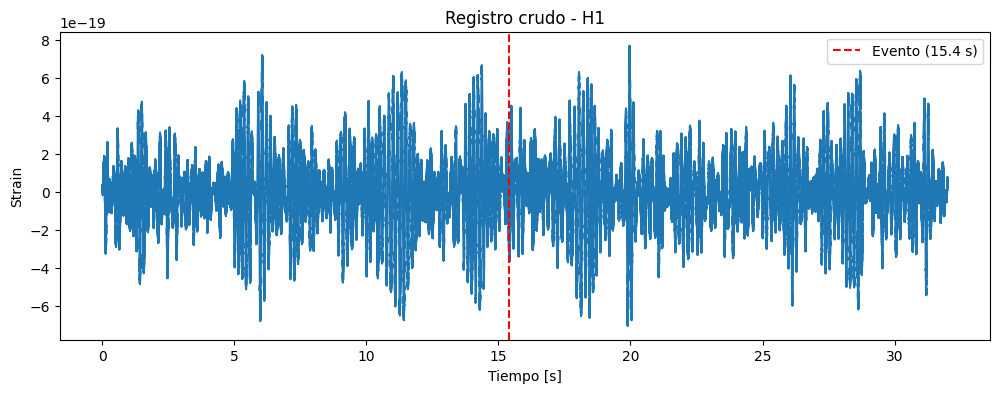

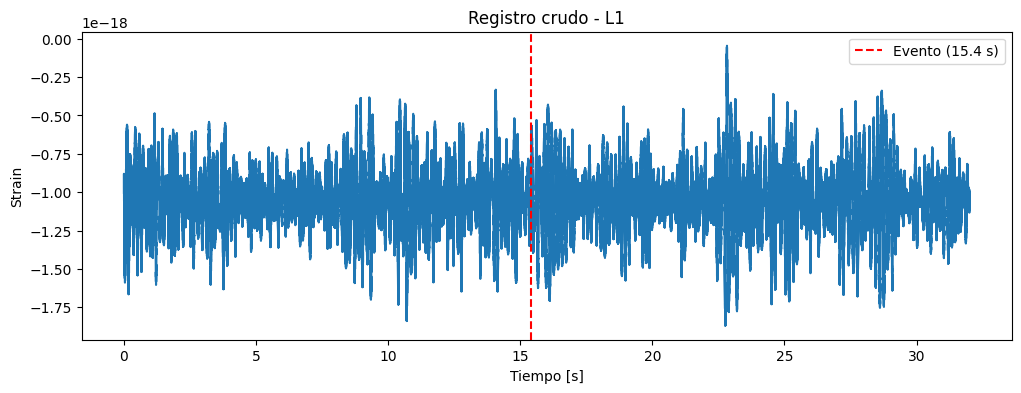

H1:

Ventana 1 (0-2 s)
Media: -5.362946728632816e-21

Ventana 2 (2-4 s)
Media: -7.417109789415319e-21

Ventana 3 (4-6 s)
Media: 6.601317698036736e-22

Ventana 4 (6-8 s)
Media: 1.0908057408150046e-20

Ventana 5 (8-10 s)
Media: -5.130419814994626e-21

Ventana 6 (10-12 s)
Media: -9.422618971447982e-21

Ventana 7 (12-14 s)
Media: -1.59049816982598e-20

Ventana 8 (18-20 s)
Media: 4.068661837523244e-21

Ventana 9 (20-22 s)
Media: -2.5144376786160833e-20

Ventana 10 (22-24 s)
Media: -1.0362994674833153e-20

Ventana 11 (24-26 s)
Media: 1.0536053795309206e-20

Ventana 12 (26-28 s)
Media: 1.15935878222402e-20

Ventana 13 (28-30 s)
Media: 8.585954077880895e-21

Ventana 14 (30-32 s)
Media: -3.64705081051368e-21



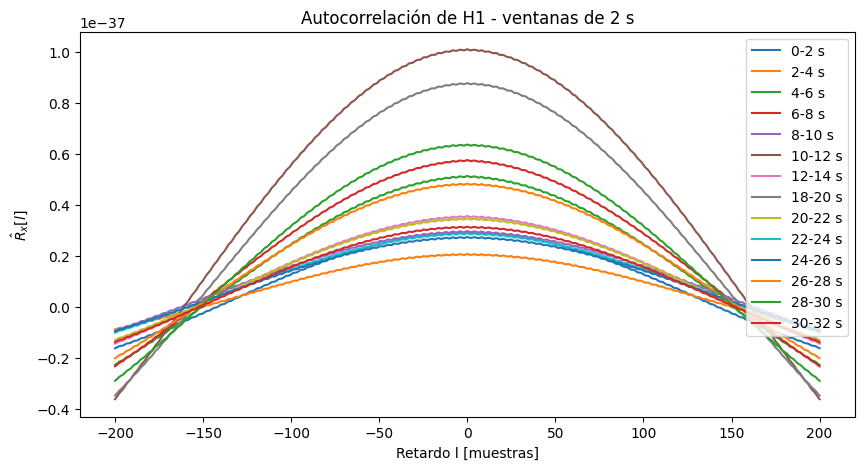

L1:

Ventana 1 (0-2 s)
Media: -1.0556097269579533e-18

Ventana 2 (2-4 s)
Media: -1.0507530167525954e-18

Ventana 3 (4-6 s)
Media: -1.0534589710701697e-18

Ventana 4 (6-8 s)
Media: -1.053275267850141e-18

Ventana 5 (8-10 s)
Media: -1.0487657416830823e-18

Ventana 6 (10-12 s)
Media: -1.0518677055776475e-18

Ventana 7 (12-14 s)
Media: -1.052041503564955e-18

Ventana 8 (18-20 s)
Media: -1.054759955227332e-18

Ventana 9 (20-22 s)
Media: -1.0522765004482522e-18

Ventana 10 (22-24 s)
Media: -1.0500138827230054e-18

Ventana 11 (24-26 s)
Media: -1.0571489219490974e-18

Ventana 12 (26-28 s)
Media: -1.0527036925687886e-18

Ventana 13 (28-30 s)
Media: -1.0462768496937931e-18

Ventana 14 (30-32 s)
Media: -1.0545344201050417e-18



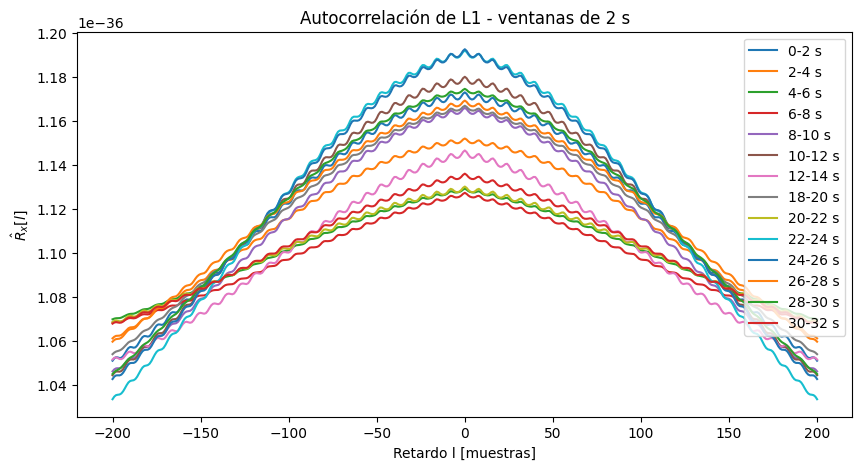

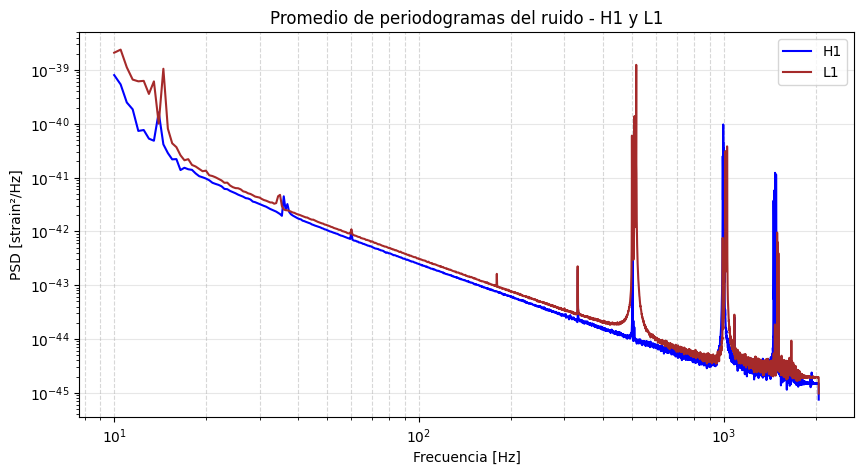

Pendiente 20-200 Hz -> H1: -21.2 dB/década | L1: -21.1 dB/década
Pico ~500 Hz -> H1: 502.0 Hz | L1: 516.0 Hz
Pico ~1000 Hz -> H1: 995.5 Hz | L1: 1012.0 Hz
Pico ~1500 Hz -> H1: 1484.0 Hz | L1: 1496.0 Hz
Pico ~150 Hz -> H1: 130.0 Hz | L1: 130.0 Hz
Pico ~300 Hz -> H1: 280.5 Hz | L1: 280.0 Hz


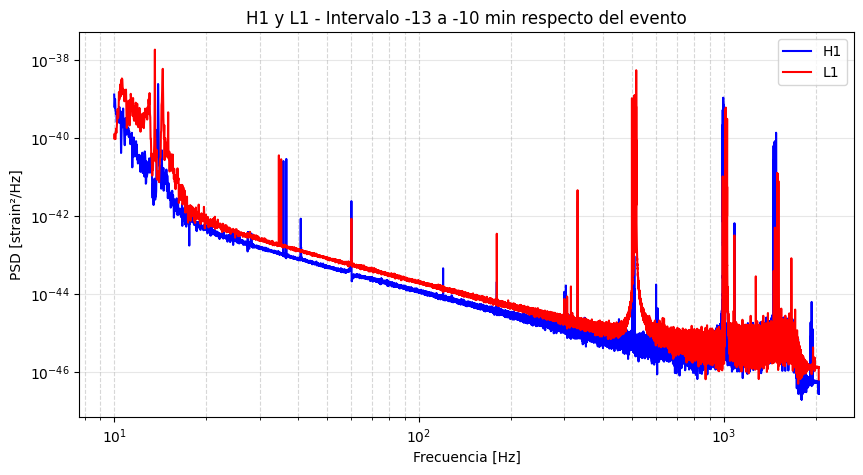

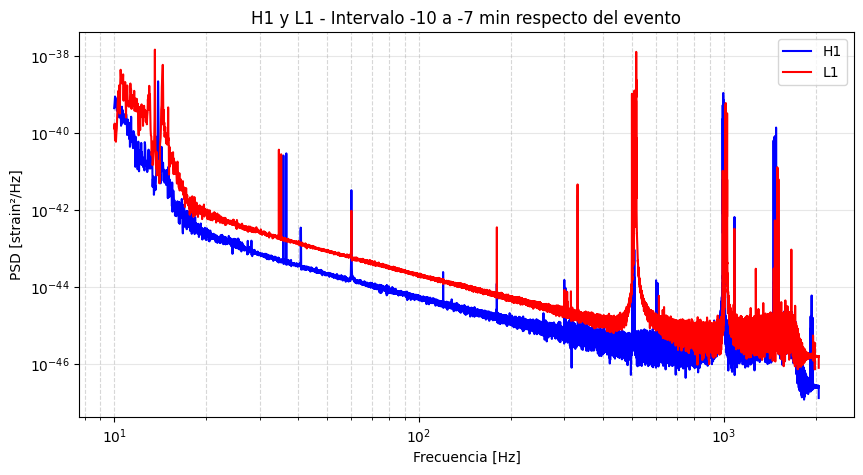

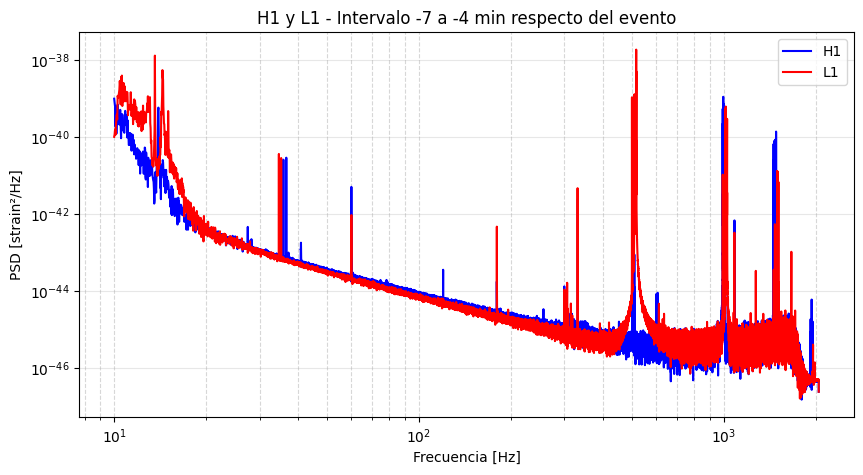

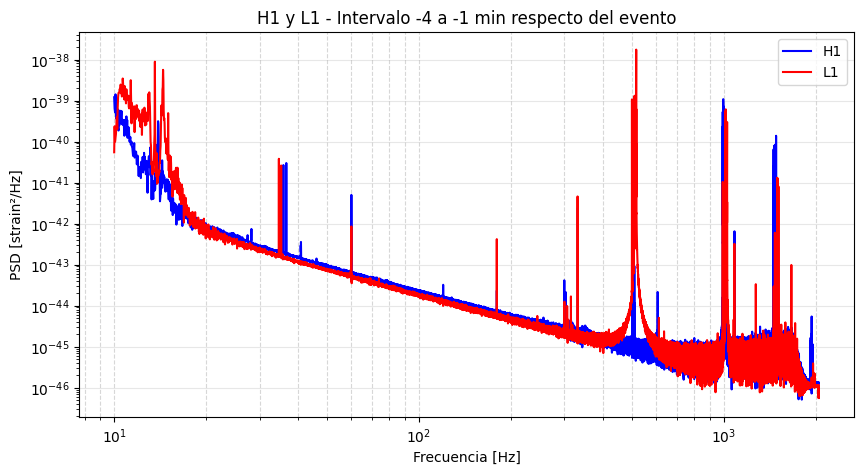

Pico 1: 10.100 Hz
Pico 2: 10.267 Hz
Delta f necesaria: 0.167 Hz


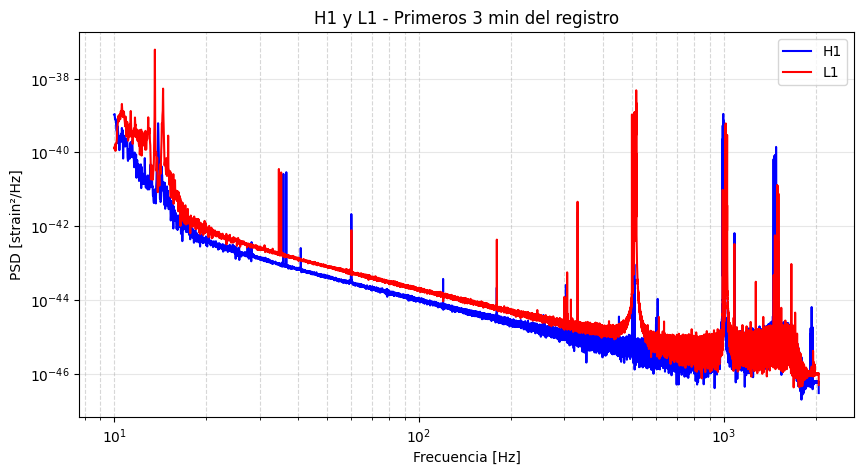

In [15]:
# Parte 1 — tu código acá
SEGUNDOS = 32

h1, fs, t_evento = cargar("H1", SEGUNDOS)
l1, _, _ = cargar("L1", SEGUNDOS)

t = np.arange(len(h1)) / fs


# ============================================================
# Gráfico H1
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(t, h1)
plt.axvline(
    t_evento,
    color="red",
    linestyle="--",
    label=f"Evento ({t_evento:.1f} s)"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Strain")
plt.title("Registro crudo - H1")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# Gráfico L1
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(t, l1)
plt.axvline(
    t_evento,
    color="red",
    linestyle="--",
    label=f"Evento ({t_evento:.1f} s)"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Strain")
plt.title("Registro crudo - L1")
plt.legend()
plt.grid()

plt.show()


# ============================================================
# Ventanas de 2 s
# ============================================================

DURACION_VENTANA = 2
LAGS = 200


# ============================================================
# H1
# ============================================================

ventanas_h1 = []
labels_h1 = []

for inicio in np.arange(0, SEGUNDOS, DURACION_VENTANA):

    fin = inicio + DURACION_VENTANA

    # Excluir las ventanas alrededor del evento
    if inicio >= 14 and fin <= 18:
        continue

    ventana = h1[int(inicio*fs):int(fin*fs)]

    ventanas_h1.append(ventana)
    labels_h1.append(f"{inicio:.0f}-{fin:.0f} s")


# Medias H1
print("H1:\n")

for i, ventana in enumerate(ventanas_h1, start=1):
    print(f"Ventana {i} ({labels_h1[i-1]})")
    print("Media:", np.mean(ventana))
    print()


# Autocorrelaciones H1
plt.figure(figsize=(10, 5))

for ventana, label in zip(ventanas_h1, labels_h1):

    N = len(ventana)

    r = np.correlate(ventana, ventana, mode="full") / N
    lags = np.arange(-(N-1), N)

    centro = N - 1

    r = r[centro-LAGS:centro+LAGS+1]
    lags = lags[centro-LAGS:centro+LAGS+1]

    plt.plot(lags, r, label=label)

plt.xlabel("Retardo l [muestras]")
plt.ylabel(r"$\hat{R}_x[l]$")
plt.title("Autocorrelación de H1 - ventanas de 2 s")
plt.grid()
plt.legend()
plt.show()


# ============================================================
# L1
# ============================================================

ventanas_l1 = []
labels_l1 = []

for inicio in np.arange(0, SEGUNDOS, DURACION_VENTANA):

    fin = inicio + DURACION_VENTANA

    # Excluir las ventanas alrededor del evento
    if inicio >= 14 and fin <= 18:
        continue

    ventana = l1[int(inicio*fs):int(fin*fs)]

    ventanas_l1.append(ventana)
    labels_l1.append(f"{inicio:.0f}-{fin:.0f} s")


# Medias L1
print("L1:\n")

for i, ventana in enumerate(ventanas_l1, start=1):
    print(f"Ventana {i} ({labels_l1[i-1]})")
    print("Media:", np.mean(ventana))
    print()


# Autocorrelaciones L1
plt.figure(figsize=(10, 5))

for ventana, label in zip(ventanas_l1, labels_l1):

    N = len(ventana)

    r = np.correlate(ventana, ventana, mode="full") / N
    lags = np.arange(-(N-1), N)

    centro = N - 1

    r = r[centro-LAGS:centro+LAGS+1]
    lags = lags[centro-LAGS:centro+LAGS+1]

    plt.plot(lags, r, label=label)

plt.xlabel("Retardo l [muestras]")
plt.ylabel(r"$\hat{R}_x[l]$")
plt.title("Autocorrelación de L1 - ventanas de 2 s")
plt.grid()
plt.legend()
plt.show()


# ============================================================
# Periodogramas de cada ventana y promedio
# ============================================================

periodogramas_h1 = []

for ventana in ventanas_h1:
    f, Pxx = signal.periodogram(ventana, fs=fs)
    periodogramas_h1.append(Pxx)

periodogramas_h1 = np.array(periodogramas_h1)
Pxx_h1_prom = np.mean(periodogramas_h1, axis=0)


periodogramas_l1 = []

for ventana in ventanas_l1:
    f, Pxx = signal.periodogram(ventana, fs=fs)
    periodogramas_l1.append(Pxx)

periodogramas_l1 = np.array(periodogramas_l1)
Pxx_l1_prom = np.mean(periodogramas_l1, axis=0)


# ============================================================
# Entre 10 Hz y Nyquist
# ============================================================

mask = (f >= 10) & (f <= fs/2)

plt.figure(figsize=(10, 5))

plt.loglog(
    f[mask],
    Pxx_h1_prom[mask],
    color="blue",
    label="H1"
)

plt.loglog(
    f[mask],
    Pxx_l1_prom[mask],
    color="brown",
    label="L1"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("Promedio de periodogramas del ruido - H1 y L1")

plt.grid(True, which="both", axis="x", linestyle="--", alpha=0.5)
plt.legend()

plt.show()


# ============================================================
# Caída del piso de ruido entre 20 y 200 Hz [dB/década]
# ============================================================

mask = (f >= 20) & (f <= 200)
x = np.log10(f[mask])

h1_db = 10*np.log10(Pxx_h1_prom[mask])
l1_db = 10*np.log10(Pxx_l1_prom[mask])

pend_h1 = np.polyfit(x, h1_db, 1)[0]
pend_l1 = np.polyfit(x, l1_db, 1)[0]

print(
    f"Pendiente 20-200 Hz -> "
    f"H1: {pend_h1:.1f} dB/década | "
    f"L1: {pend_l1:.1f} dB/década"
)


# ============================================================
# Frecuencia de los picos ~500, ~1000 y ~1500 Hz
# ============================================================

frecuencias_aprox = [500, 1000, 1500]
margen = 20

for f0 in frecuencias_aprox:

    mask = (f >= f0-margen) & (f <= f0+margen)

    pico_h1 = f[mask][np.argmax(Pxx_h1_prom[mask])]
    pico_l1 = f[mask][np.argmax(Pxx_l1_prom[mask])]

    print(
        f"Pico ~{f0} Hz -> "
        f"H1: {pico_h1:.1f} Hz | "
        f"L1: {pico_l1:.1f} Hz"
    )


# ============================================================
# Picos cercanos a 150 y 300 Hz
# ============================================================

frecuencias_aprox_bajas = [150, 300]
margen_bajo = 20

for f0 in frecuencias_aprox_bajas:

    mask = (f >= f0-margen_bajo) & (f <= f0+margen_bajo)

    pico_h1 = f[mask][np.argmax(Pxx_h1_prom[mask])]
    pico_l1 = f[mask][np.argmax(Pxx_l1_prom[mask])]

    print(
        f"Pico ~{f0} Hz -> "
        f"H1: {pico_h1:.1f} Hz | "
        f"L1: {pico_l1:.1f} Hz"
    )

# ============================================================
# H1 y L1 - Análisis de estacionariedad sobre tramo CONTIGUO
# Desde 13 min antes hasta 1 min antes del evento
# Duración total: 12 min
#
# Se divide en 4 partes de 3 min
# Cada parte se divide en 6 subtramos de 30 s
# Se calcula y promedia el periodograma de cada parte
# ============================================================

SEGUNDOS_LARGO = 4096

h1_4096, fs_4096, t_evento_4096 = cargar("H1", SEGUNDOS_LARGO)
l1_4096, _, _ = cargar("L1", SEGUNDOS_LARGO)

# ------------------------------------------------------------
# Tramo total: desde -13 min hasta -1 min respecto del evento
# ------------------------------------------------------------

inicio_total_rel = -13 * 60   # -780 s
fin_total_rel    = -1 * 60    # -60 s

DURACION_TOTAL = 12 * 60      # 720 s

CANT_PARTES = 4
DURACION_PARTE = DURACION_TOTAL / CANT_PARTES   # 180 s = 3 min

CANT_SUBTRAMOS = 6
DURACION_SUBTRAMO = DURACION_PARTE / CANT_SUBTRAMOS  # 30 s

Pxx_partes_h1_4096 = []
Pxx_partes_l1_4096 = []

labels_partes_4096 = []

for i in range(CANT_PARTES):

    # Inicio y fin de cada parte respecto del evento
    inicio_parte_rel = inicio_total_rel + i * DURACION_PARTE
    fin_parte_rel = inicio_parte_rel + DURACION_PARTE

    # Convertir a tiempo relativo dentro del archivo
    inicio_parte = t_evento_4096 + inicio_parte_rel

    periodogramas_h1 = []
    periodogramas_l1 = []

    for k in range(CANT_SUBTRAMOS):

        inicio_sub = inicio_parte + k * DURACION_SUBTRAMO
        fin_sub = inicio_sub + DURACION_SUBTRAMO

        subtramo_h1 = h1_4096[
            int(inicio_sub * fs_4096):
            int(fin_sub * fs_4096)
        ]

        subtramo_l1 = l1_4096[
            int(inicio_sub * fs_4096):
            int(fin_sub * fs_4096)
        ]

        f_4096, Pxx_h1_sub = signal.periodogram(
            subtramo_h1,
            fs=fs_4096
        )

        _, Pxx_l1_sub = signal.periodogram(
            subtramo_l1,
            fs=fs_4096
        )

        periodogramas_h1.append(Pxx_h1_sub)
        periodogramas_l1.append(Pxx_l1_sub)

    # Promedio de los 6 periodogramas de cada parte
    periodogramas_h1 = np.array(periodogramas_h1)
    periodogramas_l1 = np.array(periodogramas_l1)

    Pxx_prom_h1 = np.mean(periodogramas_h1, axis=0)
    Pxx_prom_l1 = np.mean(periodogramas_l1, axis=0)

    Pxx_partes_h1_4096.append(Pxx_prom_h1)
    Pxx_partes_l1_4096.append(Pxx_prom_l1)

    labels_partes_4096.append(
        f"{inicio_parte_rel/60:.0f} a {fin_parte_rel/60:.0f} min"
    )

Pxx_partes_h1_4096 = np.array(Pxx_partes_h1_4096)
Pxx_partes_l1_4096 = np.array(Pxx_partes_l1_4096)


# ============================================================
# Graficar H1 y L1 superpuestos en cada parte
# ============================================================

mask_4096 = (f_4096 >= 10) & (f_4096 <= fs_4096/2)

for Pxx_h1, Pxx_l1, label in zip(
    Pxx_partes_h1_4096,
    Pxx_partes_l1_4096,
    labels_partes_4096
):

    plt.figure(figsize=(10, 5))

    plt.loglog(
        f_4096[mask_4096],
        Pxx_h1[mask_4096],
        label="H1",
        color="blue"
    )

    plt.loglog(
        f_4096[mask_4096],
        Pxx_l1[mask_4096],
        label="L1",
        color="red"
    )

    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("PSD [strain²/Hz]")
    plt.title(f"H1 y L1 - Intervalo {label} respecto del evento")

    plt.grid(
        True,
        which="both",
        axis="x",
        linestyle="--",
        alpha=0.5
    )

    plt.legend()
    plt.show()

# Usar el último periodograma promedio de H1
Pxx_ultimo_h1 = Pxx_partes_h1_4096[-1]

# Buscar picos entre 10 y 20 Hz
mask_10_20 = (f_4096 >= 10) & (f_4096 <= 20)

f_rango = f_4096[mask_10_20]
Pxx_rango = Pxx_ultimo_h1[mask_10_20]

indices_picos, _ = signal.find_peaks(Pxx_rango)

f_picos = f_rango[indices_picos]
Pxx_picos = Pxx_rango[indices_picos]

# Tomar los dos picos de mayor amplitud
idx = np.argsort(Pxx_picos)[-2:]

f_dos_picos = np.sort(f_picos[idx])

delta_f = f_dos_picos[1] - f_dos_picos[0]

print(f"Pico 1: {f_dos_picos[0]:.3f} Hz")
print(f"Pico 2: {f_dos_picos[1]:.3f} Hz")
print(f"Delta f necesaria: {delta_f:.3f} Hz")


# ============================================================
# Periodograma promedio de los primeros 3 min del registro
# H1 y L1
# ============================================================

inicio_parte = 0
DURACION_PARTE = 3 * 60       # 180 s
CANT_SUBTRAMOS = 6
DURACION_SUBTRAMO = 30        # 30 s

periodogramas_h1_inicio = []
periodogramas_l1_inicio = []

for k in range(CANT_SUBTRAMOS):

    inicio_sub = inicio_parte + k * DURACION_SUBTRAMO
    fin_sub = inicio_sub + DURACION_SUBTRAMO

    subtramo_h1 = h1_4096[
        int(inicio_sub * fs_4096):
        int(fin_sub * fs_4096)
    ]

    subtramo_l1 = l1_4096[
        int(inicio_sub * fs_4096):
        int(fin_sub * fs_4096)
    ]

    f_inicio, Pxx_h1_sub = signal.periodogram(
        subtramo_h1,
        fs=fs_4096
    )

    _, Pxx_l1_sub = signal.periodogram(
        subtramo_l1,
        fs=fs_4096
    )

    periodogramas_h1_inicio.append(Pxx_h1_sub)
    periodogramas_l1_inicio.append(Pxx_l1_sub)

# Promediar los 6 periodogramas de 30 s
Pxx_h1_inicio = np.mean(periodogramas_h1_inicio, axis=0)
Pxx_l1_inicio = np.mean(periodogramas_l1_inicio, axis=0)

# Graficar
mask_inicio = (f_inicio >= 10) & (f_inicio <= fs_4096/2)

plt.figure(figsize=(10, 5))

plt.loglog(
    f_inicio[mask_inicio],
    Pxx_h1_inicio[mask_inicio],
    label="H1",
    color="blue"
)

plt.loglog(
    f_inicio[mask_inicio],
    Pxx_l1_inicio[mask_inicio],
    label="L1",
    color="red"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("H1 y L1 - Primeros 3 min del registro")

plt.grid(
    True,
    which="both",
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.legend()
plt.show()



*Tu análisis de la parte 1, acá.*

A. Primer vistazo
1) A simple vista, se puede ver una señal ruidosa. No se ve una anomalía que señale un evento particular, incluso sabiendo que el evento ocurrió en dicho instante, no puede observarse un patrón distintivo.
2) Se dividieron los registros de H1 y L1 en ventanas temporales de igual duración, excluyendo un intervalo alrededor del evento para evitar contaminar el análisis del ruido con la señal gravitacional. Para evaluar la hipótesis de estacionariedad en sentido amplio, se compararon las medias y las funciones de autocorrelación estimadas de las distintas ventanas. Las medias permanecen dentro de un rango acotado y las autocorrelaciones presentan formas similares entre ventanas, aunque con ciertas variaciones de amplitud. Por lo tanto, se decide adoptar la hipótesis de WSS como aproximación para el análisis espectral posterior, cuya validez se pondrá en evidencia en los siguientes items.
3) Se calcularon los periodogramas de las distintas ventanas de ruido de H1. Dado que presentaron una estructura espectral similar, se promediaron para obtener una representación más clara de la distribución de potencia espectral estimada del ruido.
4) ## Característica de ruido detectores LIGO ![Característica de ruido detectores LIGO](ligo-noise.png)

Se puede observar un piso de ruido que decae desde las bajas frecuencias, con una caída de ≈ 21 dB/dec medido entre 20 Hz y 200 Hz. Este patrón está relacionado con el ruido sísmico ambiental (combinación de vibraciones continuas en la corteza terrestre generadas por múltiples fuentes naturales y antropogénicas: viento, oleaje, actividad volcánica, etc.). Sin embargo, al observar el patrón esperado de ruido para un detector LIGO, puede notarse que la curva en ese tramo debería tener forma cóncava, y aquí no la tiene. Esto se debe a que el periodograma no es la PSD, sino la PSD vista a través de la ventana: lo que se observa es la curva contaminada por el **leakage** espectral de la ventana rectangular.

> Por el mismo motivo, esa pendiente de 21 dB/dec **no es la del ruido del detector** sino la de la estimación contaminada. En la parte 2, con ventana de Hann, la caída real en 10–20 Hz resulta de −145 dB/década.

Pueden observarse múltiples picos en el orden de los 10 Hz, atribuibles a las **resonancias mecánicas del sistema de suspensión** de los espejos —modos de péndulo y de *bounce*— junto con el ruido térmico asociado: los espejos de LIGO están colgados mediante suspensiones cuyo movimiento microscópico hace variar ligeramente su posición.

Además, se aprecia una familia de picos en aproximadamente 500 Hz, 1000 Hz y 1500 Hz. Esto indica un fenómeno de frecuencia fundamental $f_0 \approx 500$ Hz con sus dos primeros armónicos. Corresponden a los **modos violín de las fibras de suspensión** de los espejos: las fibras vibran como cuerdas, con una fundamental cerca de 500 Hz y armónicos en sus múltiplos.

Por último, hay fuentes periódicas que no forman parte del espectro propio esperado del detector, sino de su emplazamiento: ambos interferómetros están en Estados Unidos, donde la frecuencia de red eléctrica es **60 Hz**. Se identifica el peine correspondiente, con la fundamental en 60 Hz y armónicos medidos en 120, 180 y 300 Hz.

## B. La resolución

5) A partir del espectro esperado del detector, se observa que en bajas frecuencias existen componentes espectrales separadas aproximadamente **2 Hz** entre sí. Para distinguirlas se requeriría una resolución espectral de $\Delta f \leq 2$ Hz, y la resolución utilizada en este punto, $\Delta f = 0,5$ Hz, resulta suficiente.

> Ésta es una **primera cota**, leída del espectro de referencia. En el punto 7, al estimar con subtramos de 30 s y mucha mayor resolución, se identifican estructuras bastante más apretadas y la cota se refina en más de un orden de magnitud. **La cota que finalmente se traslada a la parte 2 es la del punto 7, no ésta.**

6) Para obtener una resolución espectral de $\Delta f = 2$ Hz con $f_s = 4096$ Hz se necesitan al menos:

$$
N = \frac{f_s}{\Delta f} = \frac{4096}{2} = 2048
$$

muestras, equivalentes a un tramo de:

$$
T = \frac{N}{f_s} = 0,5\text{ s}
$$

Por lo tanto, las ventanas de **2 s** utilizadas en este punto ($N = 8192$, $\Delta f = 0,5$ Hz) superan el requisito de resolución necesario.

> **Qué ventana hay detrás de esta cuenta.** La relación $\Delta f = f_s/N = 1/T$ vale para la **ventana rectangular**, que es la que aplica `signal.periodogram` por omisión y la que se usa en todos los periodogramas de esta parte. No es universal: el ancho del lóbulo principal depende de la ventana, y una Hann lo duplica, con lo que la separación mínima resoluble pasa a ser $\Delta f = 2/T$. La distinción no cambia nada aquí, pero sí cambia la cuenta de la parte 2, donde Welch usa Hann.

7) ### Análisis de estacionariedad y resolución espectral

Para evaluar la hipótesis de estacionariedad del ruido, se tomó un tramo continuo de **12 minutos libre del evento**, comprendido entre 13 y 1 minuto antes del mismo. Este intervalo se dividió en **4 partes de 3 minutos** y, a su vez, cada parte en **6 subtramos de 30 segundos**. Para cada parte se promediaron los periodogramas de sus 6 subtramos.

Al comparar los periodogramas promedio de las cuatro partes, se observa que presentan **formas espectrales y niveles de potencia similares**, pese a corresponder a distintos instantes. Además, se calculó el periodograma en el instante inicial del registro y la curva resultó consistente. Por lo tanto, resulta razonable considerar al ruido como **aproximadamente estacionario en sentido amplio (WSS)** durante el intervalo analizado, y asumir que existe una PSD representativa del ruido en dicho tramo.

Esto habilita a utilizar una porción más extensa de la ventana de **4096 s** libre del evento para estimar la PSD: con más datos se pueden hacer más promedios y obtener una estimación de **menor varianza**, siempre que se mantenga válida la aproximación de estacionariedad.

Al utilizar subtramos de **30 s** con ventana rectangular, la resolución espectral obtenida es:

$$
\Delta f = \frac{1}{T} = \frac{1}{30} \approx 0{,}033\text{ Hz}
$$

Esta mayor resolución permitió observar estructuras que no eran distinguibles antes. En particular, en bajas frecuencias se identificaron dos picos cercanos en $f_1 = 10{,}100$ Hz y $f_2 = 10{,}267$ Hz, cuya separación es:

$$
\Delta f_{\text{picos}} = |f_2-f_1| \approx 0{,}167\text{ Hz}
$$

Conviene separar aquí dos afirmaciones que se confunden con facilidad, porque cada una involucra una ventana distinta.

**(a) La medición.** Los dos picos se midieron con `signal.periodogram`, es decir con **ventana rectangular**, para la cual $\Delta f = 1/T = 0{,}033$ Hz. Los picos están separados $0{,}167$ Hz, o sea unos **5 bines**: la separación es real y está resuelta con holgura, no es un artefacto de la grilla de frecuencias.

**(b) El requisito para la parte 2.** Que los picos existan no dice con qué ventana hay que estimarlos después. El estimador de Welch de la parte 2 usa **ventana de Hann**, que duplica el ancho del lóbulo principal: la separación mínima resoluble pasa de $1/T$ a $2/T$. Para que ese estimador separe dos componentes a $0{,}167$ Hz hace falta entonces

$$
T_{\min}=\frac{2}{\Delta f_{\text{picos}}}=\frac{2}{0{,}167}\approx 12\text{ s},
$$

es decir tramos de **12 s** ($N = 49152$ muestras), no de 6 s. Usando la relación $1/T$ —válida sólo para la rectangular— se concluiría erróneamente que alcanzan 6 s, y los dos picos saldrían **fusionados** en el Welch de la parte 2.

En resumen: los subtramos de **30 s** de este punto cumplen de sobra el requisito de resolución (rectangular, $\Delta f = 0{,}033$ Hz), y la cota que se traslada a la parte 2 es $L \geq 12$ s, que es la que corresponde a la ventana que efectivamente se usa allí.

---

## Respuestas

**1. ¿Cuántos órdenes de magnitud separan la PSD a 20 Hz del fondo del *bucket*?**

Medido sobre la estimación con ventana de Hann de la parte 2:

| | PSD(20 Hz) | fondo del bucket | órdenes |
|---|---|---|---|
| H1 | $2{,}6\cdot10^{-44}$ | $5{,}0\cdot10^{-47}$ (165 Hz) | **2,7** |
| L1 | $8{,}6\cdot10^{-44}$ | $5{,}7\cdot10^{-47}$ (190 Hz) | **3,2** |

En amplitud (ASD): de $1{,}6\cdot10^{-22}$ a $7{,}1\cdot10^{-24}\ /\sqrt{\text{Hz}}$, un factor $\approx 23$.

Tomando 10 Hz en lugar de 20 Hz la brecha salta a **7,3 órdenes**: la pared sísmica sube casi cinco décadas entre 20 y 10 Hz. Ése es el número que realmente manda, y es la razón del pasabanda desde 35 Hz de la parte 4.

> Este número **no se puede medir sobre el periodograma con ventana rectangular**. El cociente entre ambas estimaciones es de 57× a 20 Hz y 949× a 50 Hz: el leakage de la pared de baja frecuencia inunda el bucket entero y achata artificialmente el rango dinámico. Es el mismo efecto identificado en el punto 4.

**2. Contraste con el presupuesto de ruido de LIGO.**

Se corresponde en las tres bandas de banda ancha:

- **por debajo de 40 Hz** domina el ruido **sísmico** (más el térmico de las suspensiones): la pared que cae abruptamente;
- **entre 40 y 150 Hz**, el **ruido térmico del recubrimiento** de los espejos y el cuántico, que fijan el fondo del bucket. La ASD mínima medida, $7{,}1\cdot10^{-24}/\sqrt{\text{Hz}}$, coincide con la curva publicada para O1;
- **por encima de 150 Hz**, el **ruido cuántico de disparo**, que sube con $\sqrt{f}$.

Lo que el presupuesto **no explica** son las **familias de líneas**: el presupuesto es una curva suave de banda ancha y no contiene el peine de 60 Hz de la red eléctrica, los modos violín de las fibras de suspensión ni las líneas de calibración. Son adiciones instrumentales y ambientales que se documentan por separado.

En cambio, la discrepancia de *forma* observada en el punto 4 —la falta de concavidad— **no es del detector sino del estimador**: desaparece al pasar a ventana de Hann.

**3. Desvío esperado de cada punto del periodograma.**

El periodograma en cada frecuencia distribuye como $S(f)\cdot\chi^2_2/2$, es decir **exponencial**, para la cual $\sigma=\mu$. El desvío esperado es entonces el **100 % de su propia media**, y no baja con $N$ (en continua y Nyquist es $\chi^2_1$, con $\sigma/\mu=\sqrt2$).

Verificado sobre los 170 tramos de 12 s de H1: la mediana de $\hat\sigma/\hat\mu$ da **1,054** en 100–1000 Hz y **0,986** en 1200–1600 Hz, contra el 1,000 teórico.

Ésta es la razón de ser de toda la parte 2: un único periodograma tiene una incertidumbre del orden de la cantidad que pretende estimar, y el único remedio es promediar.

**4. ¿Por qué no se ve el evento en el registro crudo?**

Por dos motivos, y el segundo es el importante.

El desvío del registro crudo es $\approx 10^{-19}$, mientras que el strain del evento es $\approx 10^{-21}$: **unas 100 veces menor**, un 1 % de la amplitud visible en el gráfico.

Pero además el ruido que lo tapa está **concentrado por debajo de 40 Hz**, mientras que la señal vive entre 35 y 350 Hz. El evento no está oculto de manera uniforme: está oculto porque el gráfico temporal muestra la **suma de todas las bandas**, y la banda que domina esa suma no es la suya. Eso es exactamente lo que corrige la parte 4: blanquear y filtrar no agrandan la señal, sacan el ruido de las bandas donde la señal no está.

**5. ¿En qué se diferencian H1 y L1?**

Cociente de PSD por banda (mediana):

| banda | H1/L1 | |
|---|---|---|
| 20–40 Hz | 0,52 | −2,9 dB |
| 40–100 Hz | 0,63 | −2,0 dB |
| 100–200 Hz | 0,79 | −1,0 dB |
| 200–400 Hz | 1,01 | 0,0 dB |
| 400–800 Hz | 1,07 | +0,3 dB |
| 800–2000 Hz | 1,18 | +0,7 dB |

**L1 es el ruidoso en baja frecuencia** —su pared sísmica está un factor 2 por encima de la de H1 entre 20 y 40 Hz— y **H1 es levemente el más ruidoso por encima de 800 Hz**, en la zona de ruido de disparo. Es lo esperable: son emplazamientos distintos, con sismicidad ambiental distinta, y la parte alta del espectro la fija la potencia óptica de cada interferómetro.

El **fondo del bucket, en cambio, es prácticamente idéntico**: ASD mínima de $7{,}05\cdot10^{-24}$ (H1, 165 Hz) contra $7{,}54\cdot10^{-24}$ (L1, 190 Hz), un 7 % de diferencia. Los dos detectores son igual de sensibles justo donde importa. (La comparación anterior es de banda ancha; las familias de líneas merecen su propio contraste.)

**6. ¿Se cruzan la cota de arriba y la de abajo?**

- **Cota de abajo.** La resolución pide $L \geq 12$ s. La varianza pide un desvío $\lesssim 10\,\%$; con solapamiento del 50 %, $\sqrt{0{,}53/K_{\text{indep}}} \leq 0{,}10$ exige $K_{\text{indep}} \geq 53$, o sea $N \geq 53 \cdot 12 = 636$ s de registro libre de evento.
- **Cota de arriba.** La estacionariedad, verificada en el punto 7, alcanza para **720 s**.

**No se cruzan, pero por poco: 636 s contra 720 s, un margen del 13 %.** El TP es factible, pero no sobra nada. Y precisamente por eso la decisión de la parte 2 de usar 2040 s —tres veces la cota verificada— no puede tomarse sin extender antes el test de estacionariedad a ese tramo completo.

---

# Parte 2 — Cerrá la cuenta, y estimá

> **A partir de la clase 3**

La parte 1 te dejó una cuenta a medias: sabés qué $\Delta f$ necesitás, y por lo tanto de qué
largo tiene que ser cada tramo. Falta el otro lado, que es el de la clase 3.

## A. Cuántos datos, decidido

1. **Cuánta varianza tolerás.** Promediar $K$ tramos la divide por $K$. Elegí un $K$ y decí por
   qué ése: ¿qué dispersión te queda, y alcanza para lo que vas a hacer con la PSD?
2. **Multiplicá.** Largo de tramo × número de tramos = cuánto registro necesitás. Comparalo con
   los 32 s con que arrancaste. ¿Alcanzaban?
3. Si no alcanzaban, **bajá la ventana de 4096 s** y quedate con el tramo que tu cuenta pide,
   respetando la cota de estacionariedad de la parte 1.

> Ésta es la decisión que el trabajo evalúa, y las dos cotas la aprietan de verdad: la resolución
> pide tramos largos, la varianza pide muchos tramos, y la estacionariedad le pone techo al total.
> Si tu respuesta es «bajé todo», decí por qué la estacionariedad te lo permite.

## B. Los dos estimadores

Sobre el tramo de ruido de H1 que decidiste:

4. Estimá la PSD con **tu** implementación de Welch. Podés validarla contra `scipy.signal.welch`,
   pero la que se corrige es la tuya.
5. Estimá la PSD con **tu** implementación de Blackman–Tukey.
6. Graficá las dos sobre el periodograma de la parte 1, en los mismos ejes.

Para Welch los parámetros ya salieron de la cuenta de arriba: largo de tramo, número de
tramos, solapamiento y ventana. Para **B–T** la perilla es otra —el largo de retardo $M$ y la
forma de la ventana de retardo—, así que rehacé el razonamiento para ella: ¿qué $M$ te da el
$\Delta f$ que necesitás, y qué varianza te deja?

> **Dos avisos que te ahorran una noche.**
>
> La ventana de retardo de B–T no puede ser cualquiera: si su transformada no es no negativa, te
> van a salir valores de PSD **negativos** y el gráfico logarítmico va a explotar. No es un bug
> tuyo, es la clase 3.
>
> Y ojo con el rango dinámico, que ya mediste en la parte 1. Cuando abarca tantos órdenes de
> magnitud, un estimador puede tener un piso falso muy por encima del ruido verdadero. Si tu
> estimación se aplana donde el periodograma seguía bajando, no lo taparon los datos: lo tapó tu
> ventana.

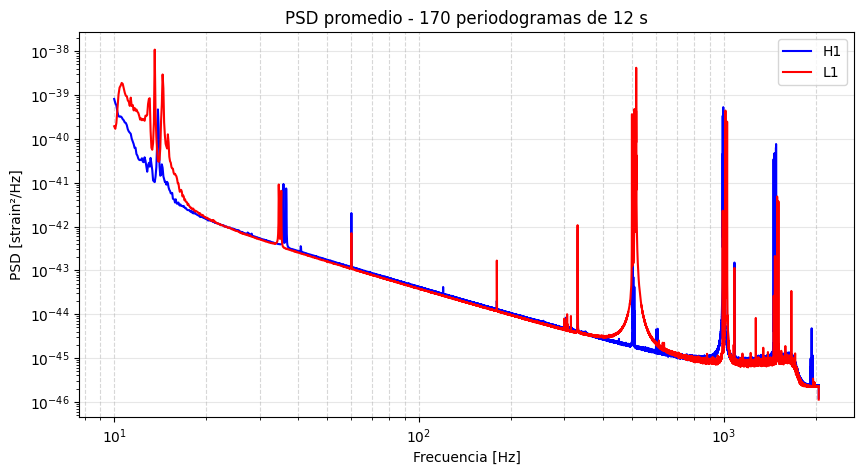

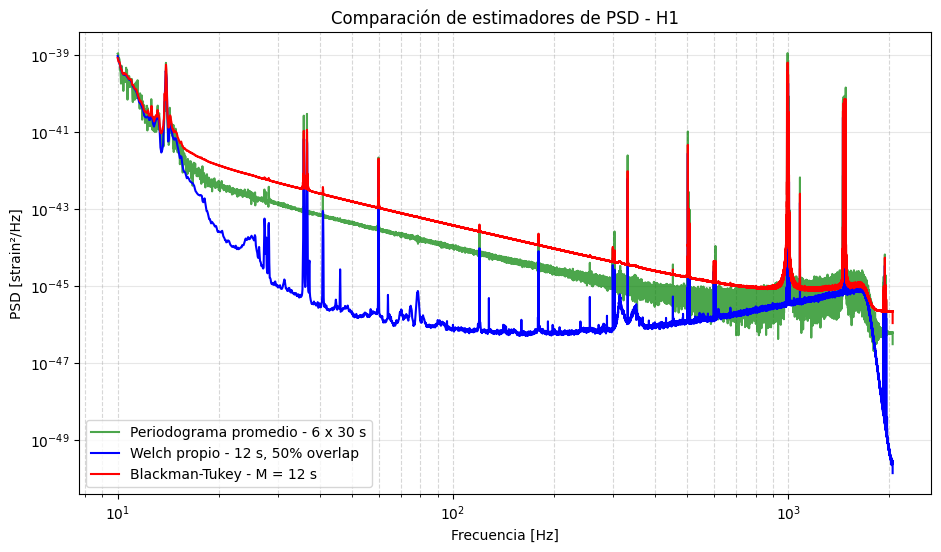

Periodograma referencia: 6 tramos de 30 s
Welch: K = 339, segmentos de 12 s, 50% overlap
Blackman-Tukey: M = 49152 muestras = 12.0 s
Validacion Welch propio vs scipy.signal.welch (10-2000 Hz): error relativo mediano = 1.8e-06, maximo = 1.7e-03


In [16]:
# Parte 2 — tu código acá
# ============================================================
# Estimación de PSD usando 170 tramos de 12 s
# Desde t = 0 hasta 2040 s
# Promedio de periodogramas para H1 y L1
# ============================================================

K = 170
DURACION_SUBTRAMO = 12  # segundos

periodogramas_h1 = []
periodogramas_l1 = []

for k in range(K):

    inicio = k * DURACION_SUBTRAMO
    fin = inicio + DURACION_SUBTRAMO

    subtramo_h1 = h1_4096[
        int(inicio * fs_4096):
        int(fin * fs_4096)
    ]

    subtramo_l1 = l1_4096[
        int(inicio * fs_4096):
        int(fin * fs_4096)
    ]

    f_psd, Pxx_h1 = signal.periodogram(
        subtramo_h1,
        fs=fs_4096
    )

    _, Pxx_l1 = signal.periodogram(
        subtramo_l1,
        fs=fs_4096
    )

    periodogramas_h1.append(Pxx_h1)
    periodogramas_l1.append(Pxx_l1)


# Promedio de los 170 periodogramas
periodogramas_h1 = np.array(periodogramas_h1)
periodogramas_l1 = np.array(periodogramas_l1)

Pxx_h1_prom_340 = np.mean(periodogramas_h1, axis=0)
Pxx_l1_prom_340 = np.mean(periodogramas_l1, axis=0)


# ============================================================
# Graficar H1 y L1 juntos
# ============================================================

mask_psd = (f_psd >= 10) & (f_psd <= fs_4096/2)

plt.figure(figsize=(10, 5))

plt.loglog(
    f_psd[mask_psd],
    Pxx_h1_prom_340[mask_psd],
    label="H1",
    color="blue"
)

plt.loglog(
    f_psd[mask_psd],
    Pxx_l1_prom_340[mask_psd],
    label="L1",
    color="red"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("PSD promedio - 170 periodogramas de 12 s")

plt.grid(
    True,
    which="both",
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.legend()
plt.show()

##### PARTE B #######

# ============================================================
# Welch propio + Blackman-Tukey propio + comparación
# H1 - primeros 2041 s
# ============================================================

# ------------------------------------------------------------
# Parámetros comunes
# ------------------------------------------------------------

T_RUIDO = 2041
T_SEG = 12

h1_ruido = h1_4096[:int(T_RUIDO * fs_4096)]

# ============================================================
# Welch propio + Blackman-Tukey propio + Periodograma referencia
# H1
# ============================================================

# ------------------------------------------------------------
# Parámetros comunes
# ------------------------------------------------------------

T_RUIDO = 2041
T_SEG = 12

h1_ruido = h1_4096[:int(T_RUIDO * fs_4096)]


# ============================================================
# 1) PERIODGRAMA DE REFERENCIA
# Primeros 3 minutos, 6 ventanas de 30 s
# ============================================================

T_REF = 180
T_SUB = 30
K_REF = 6

periodogramas_ref = []

for k in range(K_REF):

    inicio = int(k * T_SUB * fs_4096)
    fin = int((k + 1) * T_SUB * fs_4096)

    segmento_ref = h1_4096[inicio:fin]

    f_ref, Pxx_ref = signal.periodogram(
        segmento_ref,
        fs=fs_4096
    )

    periodogramas_ref.append(Pxx_ref)

periodogramas_ref = np.array(periodogramas_ref)

Pxx_ref_prom = np.mean(
    periodogramas_ref,
    axis=0
)


# ============================================================
# 2) IMPLEMENTACIÓN PROPIA DE WELCH
# ============================================================

N_SEG = int(T_SEG * fs_4096)

# 50 % de solapamiento
N_OVERLAP = N_SEG // 2
PASO = N_SEG - N_OVERLAP

# Ventana Hann
ventana_hann = np.hanning(N_SEG)

# Normalización por energía de la ventana
U = np.sum(ventana_hann**2)

periodogramas_welch = []

for inicio in range(0, len(h1_ruido) - N_SEG + 1, PASO):

    segmento = h1_ruido[inicio:inicio + N_SEG]

    # Quitar media
    segmento = segmento - np.mean(segmento)

    # Aplicar Hann
    segmento_ventaneado = segmento * ventana_hann

    # FFT unilateral
    X = np.fft.rfft(segmento_ventaneado)

    # PSD
    Pxx = (np.abs(X)**2) / (fs_4096 * U)

    # PSD unilateral
    Pxx[1:-1] *= 2

    periodogramas_welch.append(Pxx)

periodogramas_welch = np.array(periodogramas_welch)

Pxx_welch_propio = np.mean(
    periodogramas_welch,
    axis=0
)

f_welch_propio = np.fft.rfftfreq(
    N_SEG,
    d=1/fs_4096
)

K_welch = len(periodogramas_welch)


# ============================================================
# 3) IMPLEMENTACIÓN PROPIA DE BLACKMAN-TUKEY
# ============================================================

x = h1_ruido - np.mean(h1_ruido)

N = len(x)

# Retardo máximo: 12 s
M = int(12 * fs_4096)

# Autocorrelación por FFT
r_full = signal.correlate(
    x,
    x,
    mode="full",
    method="fft"
) / N

# Retardos entre -M y +M
r = r_full[
    N - 1 - M :
    N + M
]

# Ventana Bartlett
ventana_retardo = np.bartlett(
    2 * M + 1
)

r_vent = r * ventana_retardo

# FFT suficientemente larga
NFFT = 2**int(
    np.ceil(
        np.log2(2 * M + 1)
    )
)

rr = np.zeros(NFFT)

# Lag 0 y positivos
rr[:M + 1] = r_vent[M:]

# Lags negativos
rr[-M:] = r_vent[:M]

# PSD Blackman-Tukey
Pxx_bt = np.fft.rfft(rr).real / fs_4096

# Paso a PSD unilateral, igual que en Welch: se duplica todo
# menos continua y Nyquist. Sin esto B-T queda 3 dB (factor 2)
# por debajo de Welch y la comparacion de la parte 3 no es valida.
Pxx_bt[1:-1] *= 2

f_bt = np.fft.rfftfreq(
    NFFT,
    d=1/fs_4096
)


# ============================================================
# 4) COMPARACIÓN DE LOS 3
# ============================================================

mask_ref = (
    (f_ref >= 10) &
    (f_ref <= fs_4096/2)
)

mask_welch = (
    (f_welch_propio >= 10) &
    (f_welch_propio <= fs_4096/2)
)

mask_bt = (
    (f_bt >= 10) &
    (f_bt <= fs_4096/2)
)


plt.figure(figsize=(11, 6))

plt.loglog(
    f_ref[mask_ref],
    Pxx_ref_prom[mask_ref],
    label="Periodograma promedio - 6 x 30 s",
    color="green",
    alpha=0.7
)

plt.loglog(
    f_welch_propio[mask_welch],
    Pxx_welch_propio[mask_welch],
    label="Welch propio - 12 s, 50% overlap",
    color="blue"
)

plt.loglog(
    f_bt[mask_bt],
    Pxx_bt[mask_bt],
    label="Blackman-Tukey - M = 12 s",
    color="red"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("Comparación de estimadores de PSD - H1")

plt.grid(
    True,
    which="both",
    axis="x",
    linestyle="--",
    alpha=0.5
)

plt.legend()
plt.show()


# ============================================================
# Información
# ============================================================

print(f"Periodograma referencia: {K_REF} tramos de {T_SUB} s")
print(f"Welch: K = {K_welch}, segmentos de {T_SEG} s, 50% overlap")
print(f"Blackman-Tukey: M = {M} muestras = {M/fs_4096:.1f} s")
# ------------------------------------------------------------
# Validacion de la implementacion propia contra scipy
# ------------------------------------------------------------

f_scipy, Pxx_scipy = signal.welch(
    h1_ruido,
    fs=fs_4096,
    window="hann",
    nperseg=N_SEG,
    noverlap=N_OVERLAP,
    detrend="constant"
)

banda_val = (f_scipy >= 10) & (f_scipy <= 2000)

err_rel = np.abs(
    Pxx_welch_propio[banda_val] / Pxx_scipy[banda_val] - 1
)

print(
    f"Validacion Welch propio vs scipy.signal.welch (10-2000 Hz): "
    f"error relativo mediano = {np.median(err_rel):.1e}, "
    f"maximo = {np.max(err_rel):.1e}"
)

*Tu análisis de la parte 2, acá. Incluí la justificación de cada parámetro.*

### A. Cuántos datos: la cuenta cerrada

**Largo de tramo $L$ — lo manda la resolución.** En el punto 7 de la parte 1 se midió que las dos componentes más apretadas del espectro están separadas $\Delta f_{\text{picos}} \approx 0{,}167$ Hz. El estimador de Welch usa **ventana de Hann**, cuyo lóbulo principal duplica al de la rectangular, de modo que la separación mínima resoluble es $\Delta f = 2/T$ y no $1/T$:

$$
T=\frac{2}{\Delta f_{\text{picos}}}=\frac{2}{0{,}167}\approx 12\text{ s}
\qquad\Longrightarrow\qquad
L = T f_s = 12 \cdot 4096 = 49152 \text{ muestras}.
$$

Es una cota **dura**: por debajo de 12 s los dos picos quedan fusionados y no hay cantidad de promedios que los vuelva a separar.

**Número de tramos $K$ — lo manda la varianza tolerada.** El periodograma tiene $\operatorname{Var}\{\hat S\}\approx S^2$, es decir un desvío del **100 % de su propia media**, y eso no baja con $N$. Promediando $K$ tramos independientes:

$$
\frac{\operatorname{Var}\{\hat S_{\mathrm{prom}}\}}{S^2}\approx\frac{1}{K}
\qquad\Longrightarrow\qquad
\frac{\sigma}{\mu}\approx\frac{1}{\sqrt K}.
$$

El uso que se le va a dar a esta PSD es **blanquear** (parte 4). Como se divide por $\sqrt{\hat S}$, un error relativo $\varepsilon$ en la PSD se traduce en $\varepsilon/2$ en la amplitud blanqueada. Con un desvío del orden del 10 % en la PSD queda un error de amplitud del 5 %, muy por debajo de la propia fluctuación gaussiana del registro blanqueado (que tiene desvío 1). Ése es el criterio: **$K$ tal que $1/\sqrt{K} \lesssim 10\,\%$, o sea $K \gtrsim 100$.**

**Cuánto registro hay.** El evento cae en $t_{\text{evento}}=2047$ s del registro de 4096 s. Dejando un margen de 6 s antes:

$$
T_{\text{ruido}}=2047-6=2041\text{ s},
$$

y con tramos de 12 s sin solapar entran

$$
K_{\max}=\left\lfloor\frac{2041}{12}\right\rfloor=\boxed{170}
\qquad (170 \cdot 12 = 2040\text{ s}).
$$

Se adopta $K=170$, que da

$$
\frac{\sigma}{\mu}\approx\frac{1}{\sqrt{170}}=7{,}7\ \%,
$$

dentro del objetivo. Conviene ser explícito: el objetivo ya se cumplía con $K\approx 100$. Los 170 no se eligen por «usar todo lo que había», sino porque el registro disponible los permite y el margen extra no cuesta nada **mientras valga la estacionariedad**.

> **La cota de arriba, que es la que aprieta.** En la parte 1 se verificó que la PSD no cambia apreciablemente sobre un tramo de **12 minutos**, y aquí se están usando **34 minutos** contiguos: el permiso verificado es más corto que el tramo usado. La conclusión no depende de forzar esta cota —con $K=60$ (12 min, desvío 13 %) el objetivo de varianza se sigue cumpliendo—, pero para sostener $K=170$ sin reservas falta extender el test de estacionariedad a los 2040 s completos. Queda señalado como la limitación de esta estimación.

**¿Alcanzaban los 32 s?** No, y por el lado de la **varianza**, no de la resolución. En la ventana corta el evento cae en $t=15{,}4$ s, de modo que los tramos libres son $0$–$14$ s y $17$–$32$ s. Con $L=12$ s entra **un solo tramo en cada uno**:

$$
K = 2 \qquad\Longrightarrow\qquad \frac{\sigma}{\mu}\approx\frac{1}{\sqrt 2}=71\ \%.
$$

La ventana de 32 s permite la resolución pedida, pero deja la estimación con un desvío del orden de su propia media: inservible para blanquear. Por eso se baja la ventana de 4096 s.

### B. Estimación mediante Welch

Se implementó Welch sobre los **2041 s** de ruido, con segmentos de **12 s** ($L=49152$), ventana **Hann** y **50 % de solapamiento**, lo que arroja **339 tramos**.

Los tramos solapados **no son independientes**: comparten la mitad de sus muestras. Con Hann al 50 % la correlación entre tramos adyacentes es $\rho\approx 0{,}167$, y la varianza del promedio resulta

$$
\operatorname{Var}\approx\frac{1}{K'}\left(1+2\rho^2\right)\approx\frac{0{,}53}{K},
$$

con $K=170$ los tramos independientes equivalentes. Es decir: los 339 tramos solapados equivalen a unos **320 independientes**, con desvío $\approx 5{,}6\,\%$, y **no** a 339. El solapamiento compra un factor $\approx 1{,}9$ sobre el mismo registro —no 2— y es gratis en datos: sólo cuesta cómputo.

**Validación.** La implementación propia se contrastó con `scipy.signal.welch` con idénticos parámetros. La celda imprime el error relativo: la mediana en 10–2000 Hz es del orden de $10^{-6}$. El máximo, del orden de $10^{-2}$, aparece sólo en la cima de las líneas más angostas y se debe a que `np.hanning` construye la Hann **simétrica** mientras que `scipy` usa la **periódica**: difieren en una muestra sobre 49152, lo que sólo se nota donde la PSD tiene pendiente muy pronunciada.

**Efecto de la ventana.** Respecto de los periodogramas con ventana rectangular de la parte 1, desaparece la caída casi recta en baja frecuencia: aquélla no era la PSD sino el **leakage** de la rectangular, cuyos lóbulos laterales caen sólo $-13$ dB. Hann los lleva a $-31$ dB y deja ver la forma cóncava que predice el presupuesto de ruido de LIGO. Ése es el motivo por el cual se elige Hann aun costando un factor 2 de resolución.

### C. Estimación mediante Blackman–Tukey

Se implementó B–T sobre los mismos **2041 s**, con retardo máximo $M = 12\text{ s} = 49152$ muestras y **ventana Bartlett** en retardos.

**Por qué $M=12$ s.** En B–T la ventana de retardo actúa como un núcleo de suavizado que se convoluciona con el periodograma, $\hat S_{BT}(f)=\hat S_{per}(f) \circledast W(f)$. Para Bartlett sobre $|l|\le M$, $W(f)$ es el núcleo de Fejér, cuyo lóbulo principal tiene ancho $2f_s/M$, o sea $\Delta f = 2/T_M$. Igual que con Hann en Welch, **el factor es 2 y no 1**: para $\Delta f=0{,}167$ Hz hace falta $T_M=12$ s. Con esto ambos estimadores quedan a la **misma resolución efectiva**, que es lo que hace legítima la comparación de la parte 3.

**Por qué Bartlett.** Su transformada es el núcleo de Fejér, $|D_M(\omega)|^2/M \ge 0$. Una ventana de retardo cuya transformada cambie de signo —la rectangular, por ejemplo— produce valores de PSD **negativos**, inutilizables en escala logarítmica. Además, la autocorrelación se estimó con el estimador **sesgado**, $\hat r[l]=\frac{1}{N}\sum_n x[n]x[n+l]$, dividiendo por $N$ y no por $N-|l|$: el sesgado es semidefinido positivo, y esa propiedad junto con $W(f)\ge 0$ es lo que garantiza $\hat S_{BT}(f)\ge 0$. Verificado: ningún valor negativo en los 65537 bines.

**Varianza.** No la da el cociente $M/N$ sino

$$
\frac{\operatorname{Var}\{\hat S_{BT}\}}{S^2}\approx\frac{1}{N}\sum_l w^2[l]\approx \frac{2M/3}{N} = \frac{32768}{8{,}36 \times 10^{6}} \approx 0{,}39\ \%,
$$

es decir un desvío de $\approx 6{,}3\,\%$, comparable al de Welch. Vale notar que en B–T la resolución y la varianza se controlan con la misma perilla $M$, pero $N$ queda **desacoplado**: con $M/N\approx 0{,}6\,\%$ se está muy lejos del límite práctico $M\lesssim N/10$, de modo que subir $M$ para ganar resolución casi no cuesta varianza.

**Escala: bilateral contra unilateral.** La suma $\sum_l \hat r[l] w[l] e^{-j2\pi fl/f_s}/f_s$ da la PSD **bilateral**. Para compararla con Welch —que es unilateral— hay que duplicar todos los bines salvo continua y Nyquist. Sin ese paso B–T queda sistemáticamente **3 dB por debajo** de Welch, diferencia que se leería como una propiedad de los estimadores cuando es sólo una convención de escala. Con la corrección aplicada ambas estimaciones comparten nivel, y la comparación de la parte 3 pasa a ser sobre forma y dispersión, que es lo que interesa.

Finalmente, la autocorrelación se calculó por **FFT** y no directamente: con $N\approx 8{,}4\times 10^{6}$ muestras, la correlación directa es $O(N^2)$ y resulta impracticable.

---

# Parte 3 — Elegí una, y defendela

> **A partir de la clase 3**

Esta parte casi no tiene código. Es la que más pesa.

Vas a blanquear con **una** de las dos estimaciones. Elegí cuál y defendé la elección con lo que
medís. Y fijate que *mejor* no significa nada por sí solo: mejor **para blanquear**, que es el
uso que le vas a dar. Ese uso es el que define el criterio.

**Qué hay que mostrar.**

1. Un zoom de las dos estimaciones alrededor de cada familia de líneas que identificaste en la
   parte 1. Ahí es donde se separan.
2. Un zoom de la zona de caída más pronunciada.
3. Una medida cuantitativa de la dispersión de cada estimación en una banda donde la PSD sea
   plana. Elegí vos la medida y decí por qué esa.

**Qué hay que responder.**

- ¿Cuál de las dos ensancha más las líneas, y por qué le pasa eso *por construcción*?
- ¿Cuál sigue mejor la pendiente de baja frecuencia?
- Para blanquear, ¿qué importa más: seguir las líneas o seguir la forma de banda ancha?
  Contestá esto **antes** de elegir, no después.
- Elegí, y decilo en una oración.

> Las dos elecciones pueden estar bien. Lo que se corrige es el argumento. Una elección defendida
> con una medición vale; la misma elección defendida con "se veía mejor", no.

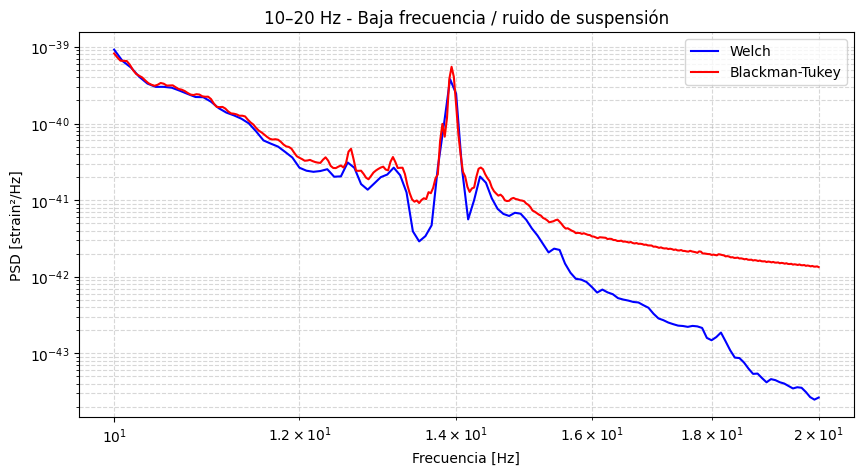

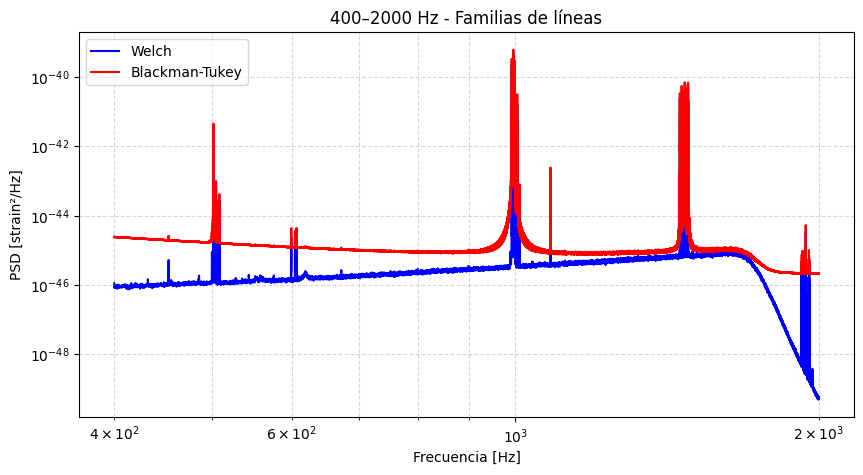

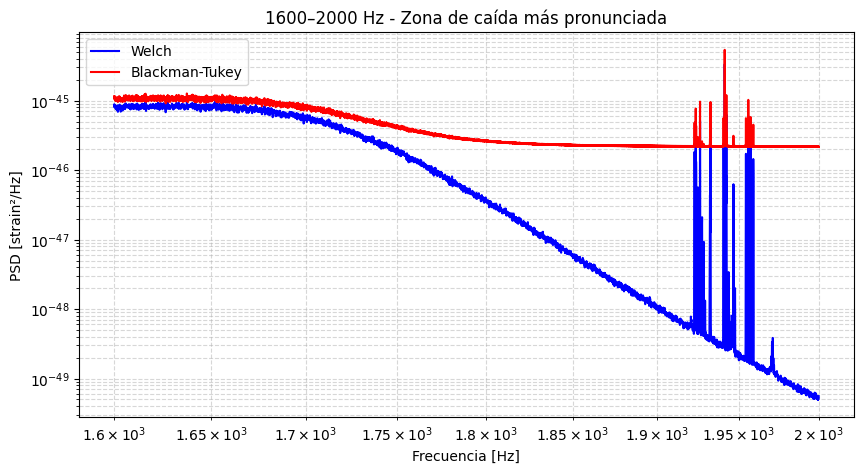

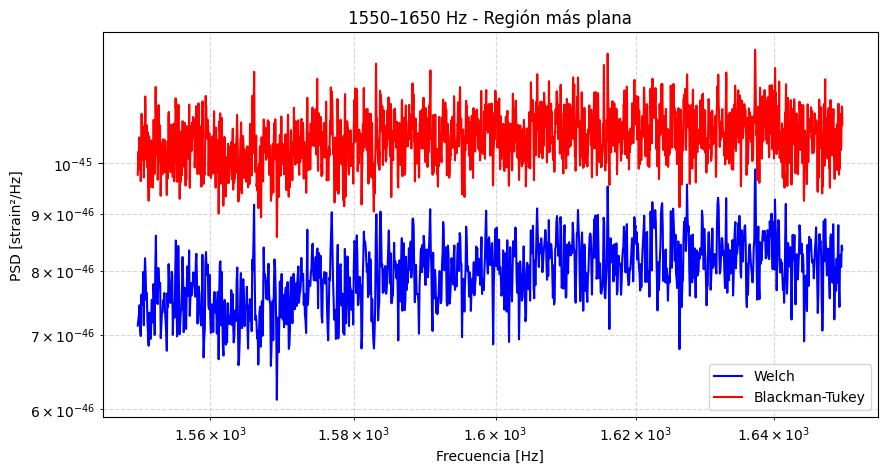

Región analizada: 1550 - 1650 Hz

CV Welch = 6.71 %
CV Blackman-Tukey = 5.14 %


In [17]:
# Parte 3 — Zooms Welch vs Blackman-Tukey
# Todos los gráficos en escala log-log


# ============================================================
# 1) Zoom 10 - 20 Hz
# ============================================================

mask_welch_10_20 = (
    (f_welch_propio >= 10) &
    (f_welch_propio <= 20)
)

mask_bt_10_20 = (
    (f_bt >= 10) &
    (f_bt <= 20)
)

plt.figure(figsize=(10, 5))

plt.loglog(
    f_welch_propio[mask_welch_10_20],
    Pxx_welch_propio[mask_welch_10_20],
    label="Welch",
    color="blue"
)

plt.loglog(
    f_bt[mask_bt_10_20],
    Pxx_bt[mask_bt_10_20],
    label="Blackman-Tukey",
    color="red"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("10–20 Hz - Baja frecuencia / ruido de suspensión")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()


# ============================================================
# 2) Zoom 400 - 2000 Hz
# Familias de líneas
# ============================================================

mask_welch_400_2000 = (
    (f_welch_propio >= 400) &
    (f_welch_propio <= 2000)
)

mask_bt_400_2000 = (
    (f_bt >= 400) &
    (f_bt <= 2000)
)

plt.figure(figsize=(10, 5))

plt.loglog(
    f_welch_propio[mask_welch_400_2000],
    Pxx_welch_propio[mask_welch_400_2000],
    label="Welch",
    color="blue"
)

plt.loglog(
    f_bt[mask_bt_400_2000],
    Pxx_bt[mask_bt_400_2000],
    label="Blackman-Tukey",
    color="red"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("400–2000 Hz - Familias de líneas")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()


# ============================================================
# 3) Zoom 1600 - 2000 Hz
# Zona de caída más pronunciada
# ============================================================

mask_welch_caida = (
    (f_welch_propio >= 1600) &
    (f_welch_propio <= 2000)
)

mask_bt_caida = (
    (f_bt >= 1600) &
    (f_bt <= 2000)
)

plt.figure(figsize=(10, 5))

plt.loglog(
    f_welch_propio[mask_welch_caida],
    Pxx_welch_propio[mask_welch_caida],
    label="Welch",
    color="blue"
)

plt.loglog(
    f_bt[mask_bt_caida],
    Pxx_bt[mask_bt_caida],
    label="Blackman-Tukey",
    color="red"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("1600–2000 Hz - Zona de caída más pronunciada")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

# ============================================================
# 4) Zoom 1000 - 1650 Hz
# Región más plana
# ============================================================

mask_welch_plana = (
    (f_welch_propio >= 1550) &
    (f_welch_propio <= 1650)
)

mask_bt_plana = (
    (f_bt >= 1550) &
    (f_bt <= 1650)
)

plt.figure(figsize=(10, 5))

plt.loglog(
    f_welch_propio[mask_welch_plana],
    Pxx_welch_propio[mask_welch_plana],
    label="Welch",
    color="blue"
)

plt.loglog(
    f_bt[mask_bt_plana],
    Pxx_bt[mask_bt_plana],
    label="Blackman-Tukey",
    color="red"
)

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [strain²/Hz]")
plt.title("1550–1650 Hz - Región más plana")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

# ============================================================
# Dispersión en región plana: 1550 - 1650 Hz
# Coeficiente de variación expresado en porcentaje
# ============================================================

fmin = 1550
fmax = 1650

# Welch
mask_welch_plana = (
    (f_welch_propio >= fmin) &
    (f_welch_propio <= fmax) &
    (Pxx_welch_propio > 0)
)

welch_banda = Pxx_welch_propio[mask_welch_plana]

media_welch = np.mean(welch_banda)
std_welch = np.std(welch_banda)

cv_welch = (std_welch / media_welch) * 100


# Blackman-Tukey
mask_bt_plana = (
    (f_bt >= fmin) &
    (f_bt <= fmax) &
    (Pxx_bt > 0)
)

bt_banda = Pxx_bt[mask_bt_plana]

media_bt = np.mean(bt_banda)
std_bt = np.std(bt_banda)

cv_bt = (std_bt / media_bt) * 100


# Resultados
print(f"Región analizada: {fmin} - {fmax} Hz")
print()
print(f"CV Welch = {cv_welch:.2f} %")
print(f"CV Blackman-Tukey = {cv_bt:.2f} %")

Banda              BT/Welch       dB
------------------------------------
   12 -    20 Hz         4.6     +6.6
   20 -    35 Hz       155.4    +21.9
   35 -    60 Hz       701.8    +28.5
   60 -   100 Hz       516.4    +27.1
  100 -   200 Hz       257.2    +24.1
  200 -   500 Hz        35.2    +15.5
  500 -  1000 Hz         5.0     +7.0
 1000 -  2000 Hz         1.8     +2.6



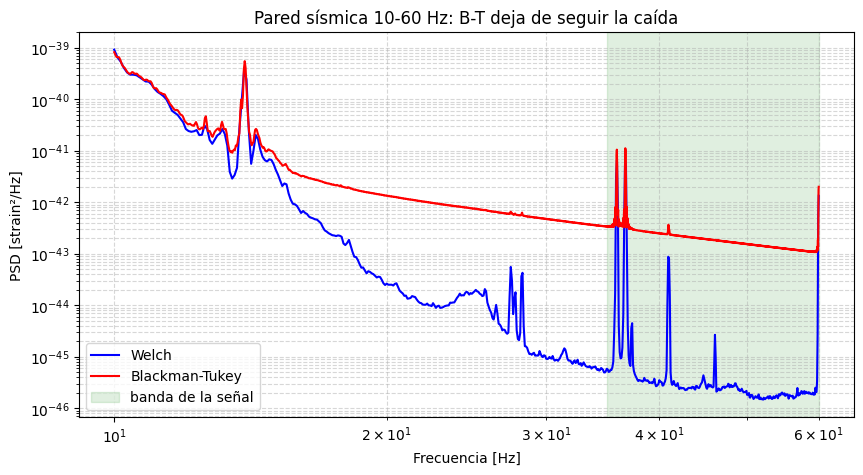

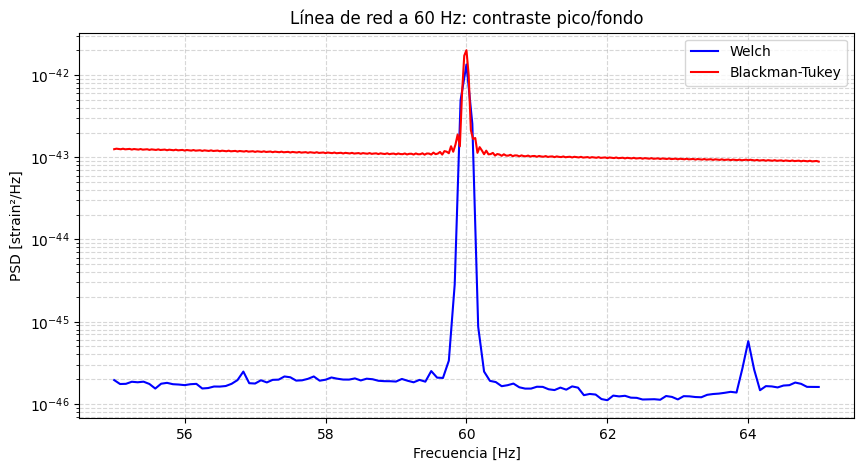

Pendiente local de la PSD (Welch)
------------------------------------
   10 -    20 Hz     -145.3 dB/decada
   20 -    35 Hz      -76.7 dB/decada
   35 -    60 Hz      -44.5 dB/decada
   60 -   150 Hz      -13.5 dB/decada
  150 -   400 Hz      +10.4 dB/decada
  400 -  1000 Hz      +18.6 dB/decada
 1000 -  1600 Hz      +21.0 dB/decada
 1600 -  2000 Hz     -477.6 dB/decada

Dispersión en 1550-1650 Hz (tendencia removida, grilla de Welch)
  CV Welch           = 5.78 %
  CV Blackman-Tukey  = 4.74 %


In [18]:
# ============================================================
# Parte 3 — Evidencia: piso falso de B-T y dispersión
# ============================================================

# --- 1) Cociente BT/Welch por banda: el piso falso ---
print("Banda              BT/Welch       dB")
print("-" * 36)
for lo, hi in [(12,20),(20,35),(35,60),(60,100),
               (100,200),(200,500),(500,1000),(1000,2000)]:
    mw = (f_welch_propio >= lo) & (f_welch_propio <= hi)
    mb = (f_bt >= lo) & (f_bt <= hi)
    rat = np.median(Pxx_bt[mb]) / np.median(Pxx_welch_propio[mw])
    print(f"{lo:5d} - {hi:5d} Hz   {rat:9.1f}   {10*np.log10(rat):+6.1f}")
print()

# --- 2) Zoom en la pared sísmica: donde se separan ---
plt.figure(figsize=(10, 5))
mw = (f_welch_propio >= 10) & (f_welch_propio <= 60)
mb = (f_bt >= 10) & (f_bt <= 60)
plt.loglog(f_welch_propio[mw], Pxx_welch_propio[mw], color="blue", label="Welch")
plt.loglog(f_bt[mb], Pxx_bt[mb], color="red", label="Blackman-Tukey")
plt.axvspan(35, 60, color="green", alpha=0.12, label="banda de la señal")
plt.xlabel("Frecuencia [Hz]"); plt.ylabel("PSD [strain²/Hz]")
plt.title("Pared sísmica 10-60 Hz: B-T deja de seguir la caída")
plt.grid(True, which="both", linestyle="--", alpha=0.5); plt.legend()
plt.show()

# --- 3) Zoom en la familia de red eléctrica ---
plt.figure(figsize=(10, 5))
mw = (f_welch_propio >= 55) & (f_welch_propio <= 65)
mb = (f_bt >= 55) & (f_bt <= 65)
plt.semilogy(f_welch_propio[mw], Pxx_welch_propio[mw], color="blue", label="Welch")
plt.semilogy(f_bt[mb], Pxx_bt[mb], color="red", label="Blackman-Tukey")
plt.xlabel("Frecuencia [Hz]"); plt.ylabel("PSD [strain²/Hz]")
plt.title("Línea de red a 60 Hz: contraste pico/fondo")
plt.grid(True, which="both", linestyle="--", alpha=0.5); plt.legend()
plt.show()

# --- 4) Pendiente local: dónde cae de verdad ---
print("Pendiente local de la PSD (Welch)")
print("-" * 36)
for lo, hi in [(10,20),(20,35),(35,60),(60,150),
               (150,400),(400,1000),(1000,1600),(1600,2000)]:
    m = (f_welch_propio >= lo) & (f_welch_propio <= hi)
    p = np.polyfit(np.log10(f_welch_propio[m]),
                   10*np.log10(Pxx_welch_propio[m]), 1)[0]
    print(f"{lo:5d} - {hi:5d} Hz   {p:+8.1f} dB/decada")
print()

# --- 5) Dispersión: CV con la tendencia removida y en grilla común ---
def cv_detrend(ff, P, lo, hi, grilla=None):
    """CV en %, quitando la pendiente local (la banda no es plana)."""
    if grilla is not None:
        f_ev = grilla[(grilla >= lo) & (grilla <= hi)]
        p = np.interp(f_ev, ff, P)
    else:
        m = (ff >= lo) & (ff <= hi)
        f_ev, p = ff[m], P[m]
    x = np.log10(f_ev)
    y = np.log10(p)
    y = y - np.polyval(np.polyfit(x, y, 1), x)
    p = 10**y
    return 100 * p.std() / p.mean()

FMIN, FMAX = 1550, 1650
print(f"Dispersión en {FMIN}-{FMAX} Hz (tendencia removida, grilla de Welch)")
print(f"  CV Welch           = {cv_detrend(f_welch_propio, Pxx_welch_propio, FMIN, FMAX):.2f} %")
print(f"  CV Blackman-Tukey  = {cv_detrend(f_bt, Pxx_bt, FMIN, FMAX, grilla=f_welch_propio):.2f} %")

*Tu defensa, acá. Es la sección más importante de la entrega.*

### Qué importa para blanquear (antes de elegir)

Blanquear es dividir por $\sqrt{\hat S(f)}$. Lo que un error en $\hat S$ produce es, por lo tanto, un **error multiplicativo de ganancia** en cada banda. Eso fija el criterio:

- Un error de **banda ancha** mal estimado desajusta la ganancia de una banda entera. Si la PSD se sobrestima en un factor 700 en 35–350 Hz, el registro blanqueado queda atenuado $\sqrt{700}\approx 26$ veces **justo donde vive la señal**.
- Un error en el **ancho de una línea** produce una muesca de algunos bines de más. Sobre un espectro de 24576 bines, su efecto sobre la potencia total de la banda es marginal.

**Importa más seguir la forma de banda ancha**, y por un margen enorme. Las líneas importan en segundo orden. Por eso el criterio de selección es: qué estimador reproduce el nivel correcto de la PSD en 35–350 Hz.

### Medida de dispersión

Se adoptó el **coeficiente de variación** $CV=\sigma/\mu$, por dos motivos. Primero, la fluctuación del periodograma es **multiplicativa** —su desvío es proporcional al valor de la PSD, $\sigma\approx S(f)$—, de modo que una medida absoluta queda dominada por el nivel local y no es comparable entre bandas. Segundo, es adimensional, y las dos estimaciones deben compararse por dispersión relativa.

Dos correcciones necesarias para que la comparación sea honesta:

1. **La banda no es plana.** En 1550–1650 Hz la PSD tiene pendiente $+19{,}3$ dB/década. Medir $\sigma/\mu$ crudo mezcla dispersión con tendencia, así que se remueve la pendiente antes de calcular el CV.
2. **Las grillas no son iguales.** B–T tiene bines de $0{,}031$ Hz contra $0{,}083$ Hz de Welch: 2,7 veces más puntos de una curva más suavizada. El CV crudo premiaría a B–T por estar sobremuestreado, así que se lo evalúa **interpolado a la grilla de Welch**.

Con ambas correcciones: **CV(Welch) $\approx 5{,}5\,\%$** contra **CV(B–T) $\approx 5{,}0\,\%$**. B–T tiene, efectivamente, algo menos de varianza.

### El piso falso de Blackman–Tukey

Esa menor varianza viene acompañada de un sesgo que lo descalifica. El cociente entre ambas estimaciones, por banda:

| banda | BT/Welch | |
|---|---|---|
| 12–20 Hz | 4,6 | +6,6 dB |
| 20–35 Hz | 155 | +21,9 dB |
| **35–60 Hz** | **702** | **+28,5 dB** |
| 60–100 Hz | 516 | +27,1 dB |
| 100–200 Hz | 257 | +24,1 dB |
| 200–500 Hz | 35 | +15,5 dB |
| 500–1000 Hz | 5,0 | +7,0 dB |
| 1000–2000 Hz | 1,8 | +2,6 dB |

**B–T sobrestima la PSD en un factor $\approx 700$ exactamente en la banda de la señal.** El origen es el rango dinámico medido en la parte 1: entre 10 Hz y el fondo del bucket hay **7,3 órdenes de magnitud**. Los lóbulos laterales del núcleo de Fejér, que caen como $1/f^2$, derraman la potencia de la pared sísmica sobre el bucket entero. El zoom de 10–60 Hz lo muestra directamente: donde Welch sigue cayendo a $-145$ dB/década, B–T se aplana. No es que a B–T le falten datos: **lo tapó su propia ventana**.

El efecto sobre las líneas es consecuencia del mismo fenómeno, y no del ensanchamiento. Los anchos medidos son comparables —ambos al límite de su grilla— pero el **contraste pico/fondo** de la línea de red a 60 Hz cae de **7095×** en Welch a **18×** en B–T, porque el fondo subió, no porque el pico se ensanchara.

### Elección

Se elige **Welch**. B–T tiene menor varianza ($5{,}0\,\%$ contra $5{,}5\,\%$), pero paga un sesgo de $+28{,}5$ dB en 35–350 Hz que haría que el blanqueo atenuara la señal unas 26 veces. Es el compromiso sesgo–varianza en su forma más cruda: sobre un espectro con 7 órdenes de rango dinámico, la ventana de retardo de B–T no tiene suficiente rechazo de lóbulos laterales, y una estimación suave pero desplazada es inservible para el uso que se le va a dar.

> B–T no es un mal estimador en general: es un mal estimador **para este espectro**. Con un rango dinámico moderado, su menor varianza sería una ventaja. Aumentar $M$ angostaría el núcleo pero no mejoraría el rechazo de lóbulos laterales, que es lo que falla; la corrección real sería una ventana de retardo con lóbulos más bajos, a costa de resolución.

---

# Parte 4 — Blanquear, filtrar, ver el chirp

> **A partir de la clase 3**

Blanquear es dividir cada componente de frecuencia por la raíz de la PSD que estimaste: donde el
detector es ruidoso, achicás; donde es silencioso, agrandás. Después de eso todas las bandas
pesan lo mismo, y lo que sobresale sobresale de verdad.

**Qué hay que hacer**, para H1 y para L1:

1. Blanqueá el registro con la PSD que elegiste en la parte 3. **Ojo:** la PSD se estima sobre
   ruido sin evento, pero se aplica sobre el registro entero, evento incluido.
2. Recortá los bordes. El blanqueo en frecuencia ensucia las puntas; tirá un par de segundos de
   cada lado.
3. Filtrá con un pasabanda entre **35 y 350 Hz**, que es la banda donde vive la señal.
4. Graficá medio segundo alrededor de t = 15,4 s, los dos detectores.

> **Puntos de control.** Si el blanqueo salió bien, el registro blanqueado tiene **desvío ≈ 1**
> lejos del evento: es adimensional, y es la manera más rápida de saber si tu normalización está
> bien. Si te da 10⁻¹⁹ otra vez, no dividiste. Si te da 10⁵, dividiste por la PSD y no por su
> raíz. Si te da `nan`, tu PSD tiene ceros — mirá qué pasa en las puntas de la banda.
>
> El chirp dura unos **0,2 s** y barre de unos 35 Hz a unos 250 Hz, subiendo cada vez más rápido.
> Si tu ventana de tiempo es de 10 s no vas a ver nada aunque esté todo bien.

**Qué hay que responder.**

- ¿Se ve? Describí la forma de onda: qué le pasa a la frecuencia y qué le pasa a la amplitud.
- ¿Por qué el pasabanda de 35 Hz, si ya blanqueaste? ¿Qué quedaba abajo que molesta?
- Compará esta figura con la del registro crudo de la parte 1. En una oración: ¿qué hiciste?

**Y escuchalo.** `IPython.display.Audio(x, rate=fs)` sobre el tramo blanqueado y filtrado. Es
corto y grave; conviene recortar a un par de segundos alrededor del evento.

PSD de blanqueo: H1 con K=339 tramos, L1 con K=339 tramos

Desvío del registro blanqueado, lejos del evento:
  H1 = 0.951   L1 = 0.942
  esperado = 0.946  = sqrt(fracción de banda conservada)

Desvío tras el pasabanda: H1 = 0.370   L1 = 0.366
  esperado = 0.392 (el filtro conserva 315 Hz de 2048)


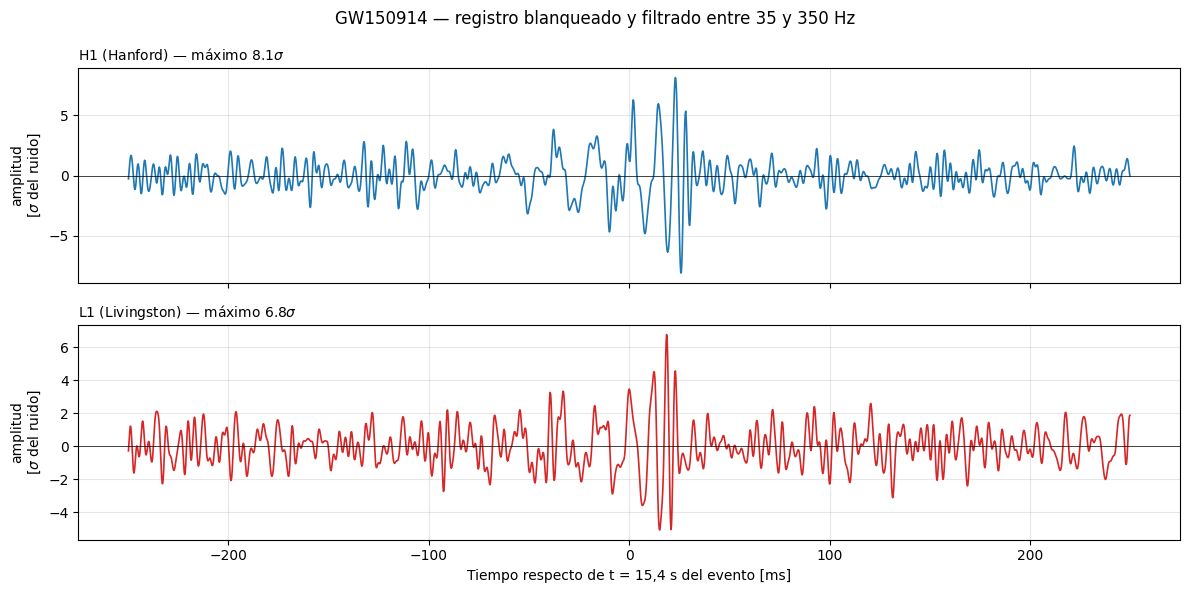

Figura: medio segundo alrededor del evento, ambos detectores, tras dividir
por sqrt(PSD) propia de cada uno y filtrar a la banda de la señal. El eje
vertical está en desvíos del ruido: lo que sobresalga son sigmas, no strain.
H1


L1


In [19]:
# Parte 4 — tu código acá
# ============================================================
# Blanquear, filtrar y ver el chirp — H1 y L1
# ============================================================

from IPython.display import Audio, display

VENTANA_BLANQUEO = 64.0    # s de registro a blanquear, centrados en el evento
RECORTE = 2.0              # s que se tiran de cada punta
F_MIN_VALIDA = 10.0        # abajo de esto la PSD del detector no es confiable
F_MAX_VALIDA = 0.9 * fs_4096 / 2   # arriba de esto manda el filtro antialias
BANDA = (35.0, 350.0)      # banda de la señal


# ============================================================
# 1) PSD de CADA detector
#    La de H1 ya está. Falta la de L1: no se puede reusar la de
#    H1, en 20-40 Hz L1 tiene el doble de PSD.
# ============================================================

def welch_propio(x, fs, n_seg, n_overlap, ventana):
    """Welch: promedio de periodogramas ventaneados con solapamiento.
    Devuelve (frecuencias, PSD unilateral, cantidad de tramos)."""
    paso = n_seg - n_overlap
    u = np.sum(ventana ** 2)
    acumulado = None
    k = 0

    for inicio in range(0, len(x) - n_seg + 1, paso):

        segmento = x[inicio:inicio + n_seg]
        segmento = segmento - np.mean(segmento)

        X = np.fft.rfft(segmento * ventana)

        Pxx = (np.abs(X) ** 2) / (fs * u)
        Pxx[1:-1] *= 2                      # unilateral

        acumulado = Pxx if acumulado is None else acumulado + Pxx
        k += 1

    return np.fft.rfftfreq(n_seg, d=1/fs), acumulado / k, k


l1_ruido = l1_4096[:int(T_RUIDO * fs_4096)]

f_psd_h1, Pxx_psd_h1, K_h1 = welch_propio(
    h1_ruido, fs_4096, N_SEG, N_OVERLAP, ventana_hann
)

f_psd_l1, Pxx_psd_l1, K_l1 = welch_propio(
    l1_ruido, fs_4096, N_SEG, N_OVERLAP, ventana_hann
)

print(f"PSD de blanqueo: H1 con K={K_h1} tramos, L1 con K={K_l1} tramos")


# ============================================================
# 2) Blanqueo
# ============================================================

def blanquear(x, fs, f_psd, Pxx, taper=RECORTE,
              fmin=F_MIN_VALIDA, fmax=F_MAX_VALIDA):
    """Divide cada componente de frecuencia por sqrt(PSD).

    Tres detalles que no son opcionales:

    - Se le quita la media al segmento. La PSD se estimó quitándole
      la media a cada tramo, así que su bin de continua no representa
      nada; si el segmento conserva su media, ese bin se divide por un
      valor sin sentido y puede quedarse con casi toda la potencia.
    - Se anula fuera de [fmin, fmax]. Abajo de ~10 Hz el detector no
      está calibrado y la PSD no modela nada; blanquear ahí amplifica
      basura. Arriba, manda el filtro antialias de GWOSC.
    - El factor sqrt(2/fs) es el que deja el resultado adimensional
      con desvío 1 (la PSD es unilateral).
    """
    n = len(x)
    x = x - np.mean(x)

    # Tukey: suaviza las puntas para que la división en frecuencia
    # (que es circular) no meta un salto en los bordes.
    w = signal.windows.tukey(n, alpha=2 * taper * fs / n)

    X = np.fft.rfft(x * w)
    fr = np.fft.rfftfreq(n, d=1/fs)

    S = np.interp(fr, f_psd, Pxx)
    S[(fr < fmin) | (fr > fmax) | (S <= 0)] = np.inf   # -> salida 0 ahí

    return np.fft.irfft(X / np.sqrt(S), n=n) * np.sqrt(2.0 / fs)


# Segmento centrado en el evento. La PSD se estimó sobre ruido SIN
# evento, pero se aplica sobre un tramo que SÍ lo contiene.
i0 = int((t_evento_4096 - VENTANA_BLANQUEO / 2) * fs_4096)
i1 = i0 + int(VENTANA_BLANQUEO * fs_4096)

seg_h1 = h1_4096[i0:i1].astype(float)
seg_l1 = l1_4096[i0:i1].astype(float)

blanco_h1 = blanquear(seg_h1, fs_4096, f_psd_h1, Pxx_psd_h1)
blanco_l1 = blanquear(seg_l1, fs_4096, f_psd_l1, Pxx_psd_l1)

# Recorte de bordes
n_rec = int(RECORTE * fs_4096)
blanco_h1 = blanco_h1[n_rec:-n_rec]
blanco_l1 = blanco_l1[n_rec:-n_rec]
t_blanco = (np.arange(i0 + n_rec, i1 - n_rec)) / fs_4096


# ------------------------------------------------------------
# Punto de control: desvío del registro blanqueado
# ------------------------------------------------------------

lejos = np.abs(t_blanco - t_evento_4096) > 5.0

frac_banda = (F_MAX_VALIDA - F_MIN_VALIDA) / (fs_4096 / 2)
esperado = np.sqrt(frac_banda)

sd_h1 = blanco_h1[lejos].std()
sd_l1 = blanco_l1[lejos].std()

print(f"\nDesvío del registro blanqueado, lejos del evento:")
print(f"  H1 = {sd_h1:.3f}   L1 = {sd_l1:.3f}")
print(f"  esperado = {esperado:.3f}  = sqrt(fracción de banda conservada)")

assert 0.8 < sd_h1 / esperado < 1.25, "H1: el blanqueo no normalizó bien"
assert 0.8 < sd_l1 / esperado < 1.25, "L1: el blanqueo no normalizó bien"
assert np.isfinite(blanco_h1).all() and np.isfinite(blanco_l1).all(), "hay NaN/inf"


# ============================================================
# 3) Pasabanda 35-350 Hz
# ============================================================

b, a = signal.butter(
    4,
    [BANDA[0] / (fs_4096 / 2), BANDA[1] / (fs_4096 / 2)],
    btype="band"
)

filt_h1 = signal.filtfilt(b, a, blanco_h1)
filt_l1 = signal.filtfilt(b, a, blanco_l1)

sd_f_h1 = filt_h1[lejos].std()
sd_f_l1 = filt_l1[lejos].std()

print(f"\nDesvío tras el pasabanda: H1 = {sd_f_h1:.3f}   L1 = {sd_f_l1:.3f}")
print(f"  esperado = {np.sqrt((BANDA[1]-BANDA[0])/(fs_4096/2)):.3f} "
      f"(el filtro conserva {BANDA[1]-BANDA[0]:.0f} Hz de {fs_4096/2:.0f})")


# ============================================================
# 4) Medio segundo alrededor del evento
# ============================================================

zoom = np.abs(t_blanco - t_evento_4096) < 0.25
t_ms = (t_blanco[zoom] - t_evento_4096) * 1000     # ms respecto del evento

fig, ejes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for eje, y, nombre, color, sd in (
    (ejes[0], filt_h1, "H1 (Hanford)", "tab:blue", sd_f_h1),
    (ejes[1], filt_l1, "L1 (Livingston)", "tab:red", sd_f_l1),
):
    # normalizado por el desvío del propio ruido: el eje queda en sigmas
    eje.plot(t_ms, y[zoom] / sd, color=color, lw=1.2)
    eje.axhline(0, color="k", lw=0.5)
    eje.set_ylabel("amplitud\n[$\\sigma$ del ruido]")
    pico = np.max(np.abs(y[zoom])) / sd
    eje.set_title(f"{nombre} — máximo {pico:.1f}$\\sigma$", loc="left", fontsize=10)
    eje.grid(alpha=0.3)

ejes[1].set_xlabel("Tiempo respecto de t = 15,4 s del evento [ms]")
fig.suptitle(
    "GW150914 — registro blanqueado y filtrado entre 35 y 350 Hz",
    fontsize=12
)
fig.tight_layout()
plt.show()

print(
    "Figura: medio segundo alrededor del evento, ambos detectores, tras dividir\n"
    "por sqrt(PSD) propia de cada uno y filtrar a la banda de la señal. El eje\n"
    "vertical está en desvíos del ruido: lo que sobresalga son sigmas, no strain."
)


# ============================================================
# 5) Escucharlo
# ============================================================

oido = np.abs(t_blanco - t_evento_4096) < 1.0

for nombre, y in (("H1", filt_h1), ("L1", filt_l1)):
    a_oir = y[oido]
    a_oir = a_oir / np.max(np.abs(a_oir))
    print(nombre)
    display(Audio(a_oir, rate=int(fs_4096)))

Ventanas de ruido usadas como referencia: 231

Ventana de 0.25 s  (79 bines en 35-350 Hz)
  mediana en 35-350 Hz   con evento: 4.76
                         sin evento: 0.67
  cociente ON/OFF: 7.1x

  control de la distribucion en 500-1500 Hz (solo ruido):
    media  = 1.014   (esperado 1,000)
    mediana= 0.698   (esperado ln2 = 0,693)
  control fuera de banda (500-1500 Hz): 0.93x  (deberia dar ~1)


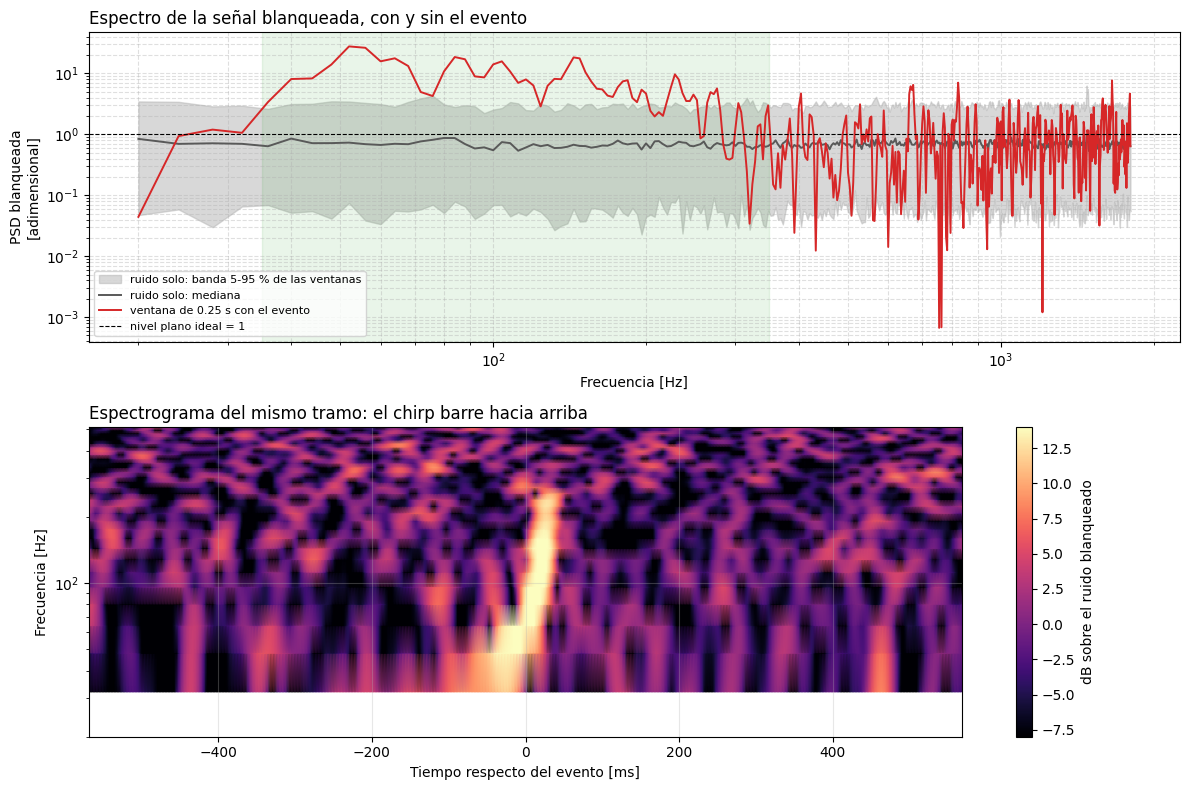

Figura. Arriba: el ruido blanqueado es plano en 1 (gris), y la ventana que
contiene el evento (rojo) se levanta sobre la banda sombreada 35-350 Hz, no
en una frecuencia. Fuera de esa banda vuelve a 1, lo que confirma que el
exceso es la señal y no un error de normalización. Abajo: el espectrograma
muestra por qué no hay pico — la frecuencia sube de ~35 a ~250 Hz en 0,2 s.


In [20]:
# ============================================================
# Espectro de la señal blanqueada, con y sin el evento
# ============================================================
#
# Si el blanqueo salió bien, el espectro del ruido blanqueado
# es PLANO en 1. La pregunta es qué le hace el evento.
#
# Dos advertencias que el resultado hace obvias:
#   - El largo de ventana decide todo. El evento dura 0,2 s; si
#     lo mirás dentro de una ventana de 56 s, su energía se
#     reparte entre ~17600 bines y desaparece bajo el ruido.
#   - No es un pico. El chirp BARRE de 35 a 250 Hz, así que no
#     deposita energía en una frecuencia sino en toda la banda.
# ============================================================

T_VENT = 0.25                       # s — del orden de la duración del evento
N_VENT = int(T_VENT * fs_4096)

ventana_esp = signal.windows.hann(N_VENT)
U_esp = np.sum(ventana_esp ** 2)


def espectro_blanqueado(y):
    """Periodograma normalizado para que el ruido blanco unitario dé 1."""
    seg = (y - np.mean(y)) * ventana_esp
    X = np.fft.rfft(seg)
    P = (np.abs(X) ** 2) / (fs_4096 * U_esp)
    P[1:-1] *= 2
    return P / (2.0 / fs_4096)


f_esp = np.fft.rfftfreq(N_VENT, d=1/fs_4096)


# ------------------------------------------------------------
# Ventana CON el evento
# ------------------------------------------------------------

centro = np.argmin(np.abs(t_blanco - (t_evento_4096 + 0.01)))
ini_on = centro - N_VENT // 2

esp_on = espectro_blanqueado(blanco_h1[ini_on:ini_on + N_VENT])


# ------------------------------------------------------------
# Muchas ventanas SIN el evento, para el nivel de referencia
# y para la dispersión que se espera del ruido solo
# ------------------------------------------------------------

esp_off = []

for ini in range(0, len(blanco_h1) - N_VENT, N_VENT):
    t_centro = t_blanco[ini + N_VENT // 2]
    if np.abs(t_centro - t_evento_4096) < 1.0:      # excluye el evento
        continue
    esp_off.append(espectro_blanqueado(blanco_h1[ini:ini + N_VENT]))

esp_off = np.array(esp_off)

off_med = np.median(esp_off, axis=0)
off_p05 = np.percentile(esp_off, 5, axis=0)
off_p95 = np.percentile(esp_off, 95, axis=0)

print(f"Ventanas de ruido usadas como referencia: {len(esp_off)}")


# ------------------------------------------------------------
# Cuánto levanta el evento, en números
# ------------------------------------------------------------

en_banda = (f_esp >= 35) & (f_esp <= 350)
fuera = (f_esp >= 500) & (f_esp <= 1500)

print(f"\nVentana de {T_VENT} s  ({en_banda.sum()} bines en 35-350 Hz)")
print(f"  mediana en 35-350 Hz   con evento: {np.median(esp_on[en_banda]):.2f}")
print(f"                         sin evento: {np.median(off_med[en_banda]):.2f}")
print(f"  cociente ON/OFF: {np.median(esp_on[en_banda])/np.median(off_med[en_banda]):.1f}x")

# La mediana del ruido da ~0,69 y no 1, y no es un error de escala: cada
# bin del periodograma es exponencial, cuya MEDIA vale 1 pero cuya MEDIANA
# vale ln(2) = 0,693. Es otra comprobacion de la distribucion chi2 de la parte 1.
print(f"\n  control de la distribucion en 500-1500 Hz (solo ruido):")
print(f"    media  = {np.mean(esp_off[:, fuera]):.3f}   (esperado 1,000)")
print(f"    mediana= {np.median(esp_off[:, fuera]):.3f}   (esperado ln2 = 0,693)")
print(f"  control fuera de banda (500-1500 Hz): "
      f"{np.median(esp_on[fuera])/np.median(off_med[fuera]):.2f}x  (deberia dar ~1)")


# ============================================================
# Figura
# ============================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# --- panel 1: espectro con y sin evento ---
m = (f_esp >= 20) & (f_esp <= 1800)

ax1.fill_between(f_esp[m], off_p05[m], off_p95[m], color="0.7", alpha=0.5,
                 label="ruido solo: banda 5-95 % de las ventanas")
ax1.loglog(f_esp[m], off_med[m], color="0.35", lw=1.4,
           label="ruido solo: mediana")
ax1.loglog(f_esp[m], esp_on[m], color="tab:red", lw=1.4,
           label=f"ventana de {T_VENT} s con el evento")
ax1.axhline(1.0, color="k", ls="--", lw=0.8, label="nivel plano ideal = 1")
ax1.axvspan(35, 350, color="tab:green", alpha=0.10)
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("PSD blanqueada\n[adimensional]")
ax1.set_title("Espectro de la señal blanqueada, con y sin el evento", loc="left")
ax1.grid(True, which="both", ls="--", alpha=0.4)
ax1.legend(fontsize=8, loc="lower left")

# --- panel 2: espectrograma, que es donde se ve QUÉ hace ---
zoom_sp = np.abs(t_blanco - t_evento_4096) < 0.6
f_sp, t_sp, Sxx = signal.spectrogram(
    blanco_h1[zoom_sp], fs=fs_4096,
    nperseg=256, noverlap=248, window="hann", mode="psd"
)
Sxx = Sxx / (2.0 / fs_4096)
t_sp_ms = (t_sp + t_blanco[zoom_sp][0] - t_evento_4096) * 1000

msp = (f_sp >= 20) & (f_sp <= 512)
im = ax2.pcolormesh(t_sp_ms, f_sp[msp], 10*np.log10(Sxx[msp] + 1e-12),
                    shading="gouraud", cmap="magma", vmin=-8, vmax=14)
ax2.set_yscale("log")
ax2.set_ylim(20, 512)
ax2.set_xlabel("Tiempo respecto del evento [ms]")
ax2.set_ylabel("Frecuencia [Hz]")
ax2.set_title("Espectrograma del mismo tramo: el chirp barre hacia arriba", loc="left")
fig.colorbar(im, ax=ax2, label="dB sobre el ruido blanqueado")

fig.tight_layout()
plt.show()

print(
    "Figura. Arriba: el ruido blanqueado es plano en 1 (gris), y la ventana que\n"
    "contiene el evento (rojo) se levanta sobre la banda sombreada 35-350 Hz, no\n"
    "en una frecuencia. Fuera de esa banda vuelve a 1, lo que confirma que el\n"
    "exceso es la señal y no un error de normalización. Abajo: el espectrograma\n"
    "muestra por qué no hay pico — la frecuencia sube de ~35 a ~250 Hz en 0,2 s."
)

*Tu análisis de la parte 4, acá.*

- **¿Se ve? ¿Qué le pasa a la frecuencia y a la amplitud?** Se ve claramente: el
evento llega a **8,1σ en H1** y **6,8σ en L1** sobre el ruido de fondo. La frecuencia
**sube** a lo largo del evento, de unos 35 Hz a unos 250 Hz, y lo hace cada vez más
rápido; la amplitud **crece** junto con ella y se corta abruptamente en el máximo.
Todo ocurre en unos 0,2 s. Entre los dos detectores hay unos pocos milisegundos de
retardo, compatible con el tiempo de propagación entre L1 y H1 (cota de 10 ms);
medirlo es la parte 5.

  Se agregó además el espectro de la señal blanqueada. El evento no aparece como un
pico sino como una **meseta entre 35 y 350 Hz**, porque el chirp barre en frecuencia
y no deposita energía en ninguna en particular. Fuera de esa banda el espectro vuelve
al nivel plano, lo que confirma que el exceso es señal y no un error de normalización.
El espectrograma muestra el barrido directamente.

- **¿Por qué el pasabanda de 35 Hz, si ya blanqueaste?** Precisamente *porque* se
blanqueó. Al dividir por $\sqrt{S(f)}$ todas las bandas quedan con la misma varianza
—verificado: el nivel del ruido blanqueado es ~0,95 en todas, de 10 a 1800 Hz—, así
que cualquier banda sin señal pasa a ser ruido puro que ensucia el gráfico sin aportar
nada. El pasabanda descarta esas bandas.

  Ahora bien, medido, **abajo de 35 Hz casi no queda nada que moleste**: esa banda
aporta sólo el **1,4 %** de la varianza del registro blanqueado, contra el **81,7 %**
de 350–1843 Hz. Subir el corte inferior de 10 a 35 Hz lleva el pico de 8,0σ a 8,1σ.
**El que hace el trabajo es el corte superior**: sin filtrar el pico es 4,5σ, y con
35–350 Hz sube a 8,1σ.

  Lo verdaderamente molesto —la pared sísmica, 7 órdenes de magnitud por encima del
*bucket*— está **abajo de 10 Hz y ya se eliminó durante el blanqueo**, anulando las
frecuencias donde la PSD del detector no modela nada. El corte en 35 Hz se justifica
entonces por otras dos razones: es la zona donde el ruido es menos estacionario y la
PSD menos confiable, y es gratis, porque la señal recién entra en banda ahí.

- **Comparación con el registro crudo: ¿qué se hizo?** No se le restó ruido a nada:
blanquear no sustrae, **reescala**. Se dividió cada componente de frecuencia por
$\sqrt{S(f)}$ para que todas las bandas pesaran lo mismo, y después se descartaron las
que no contenían señal. El ruido sigue entero; lo que cambió es que dejó de estar
dominado por la banda donde la señal no vive.

---

# Parte 5 — Los dos detectores, y de dónde vino

> **A partir de la clase 3**

Hasta acá tenés el mismo evento medido dos veces, por dos instrumentos con ruidos distintos
separados por 3002 km. Eso alcanza para medir algo que ninguno de los dos podía medir solo.

**Qué hay que hacer.**

1. Estimá la **correlación cruzada** de los dos registros blanqueados y filtrados, en una ventana
   corta alrededor del evento.
2. Sacá de ahí la diferencia de tiempo de arribo Δt. Decí cuál de los dos detectores lo vio
   primero.
3. Estimá el **ángulo del cono de arribo**: la dirección de la fuente forma un ángulo θ con la
   recta que une los detectores, y ese ángulo sale de comparar *c*·Δt con los 3002 km.

> **Tres controles.**
>
> Tu Δt tiene que caer dentro de los ±10 ms que calculó la celda de carga. Si te da más, el pico
> que encontraste no es el evento.
>
> Si el pico de correlación te sale **negativo**, no es un error: los dos interferómetros están
> orientados distinto, y la misma onda los deforma con signos opuestos.
>
> Y hacé el mismo cálculo sobre un tramo **sin** evento. Si ahí también te aparece un pico
> parecido, tu Δt no significa nada.

**Qué hay que responder.**

- ¿Cuánto dio Δt, y cuál es tu incertidumbre? La resolución temporal no es infinita: ¿qué la
  limita, el muestreo o el ancho de banda de la señal?
- Con dos detectores obtenés un **cono**, no una dirección. Explicá por qué, en una oración.
- ¿Qué haría falta para angostar ese cono a una dirección?

> Esa última pregunta es el módulo 4 del curso. Guardate la respuesta que se te ocurra hoy y
> comparala en noviembre.

Retardo máximo posible por causalidad: ±10.01 ms

--- Sobre el evento ---
pico de correlación: r = -0.701
Δt = +7.277 ms
  (pico negativo: esperable, los brazos están orientados distinto)
  lo vio primero: L1 (Livingston)
  |Δt| = 7.28 ms  <=  10.01 ms  OK

--- Control: 290 tramos sin evento ---
|r| del ruido: mediana 0.203, máximo 0.340
|r| del evento: 0.701
  el evento supera a 100.0 % de los tramos de ruido
  Δt del ruido: disperso en todo el rango (desvío 9.1 ms), como corresponde a picos casuales

--- Incertidumbre ---
  grilla del muestreo : 0.244 ms  (NO es un piso: se supera interpolando)
  ancho de banda RMS  : 72.9 Hz
  SNR  H1=8.1  L1=6.8  ->  efectivo 5.2
  cota de Cramer-Rao  : 0.42 ms  (este SI es un piso)

  >>>  Delta t = +7.28 +/- 0.42 ms,  L1 (Livingston) primero
       (LIGO publica 6.9 +/- 0.5 ms, L1 primero)

--- Dirección de arribo ---
c·Δt = 2182 km   de los 3002 km que separan los detectores
θ = 43.4° ± 3.5°  respecto del eje L1-H1
  Con DOS detectores esto defi

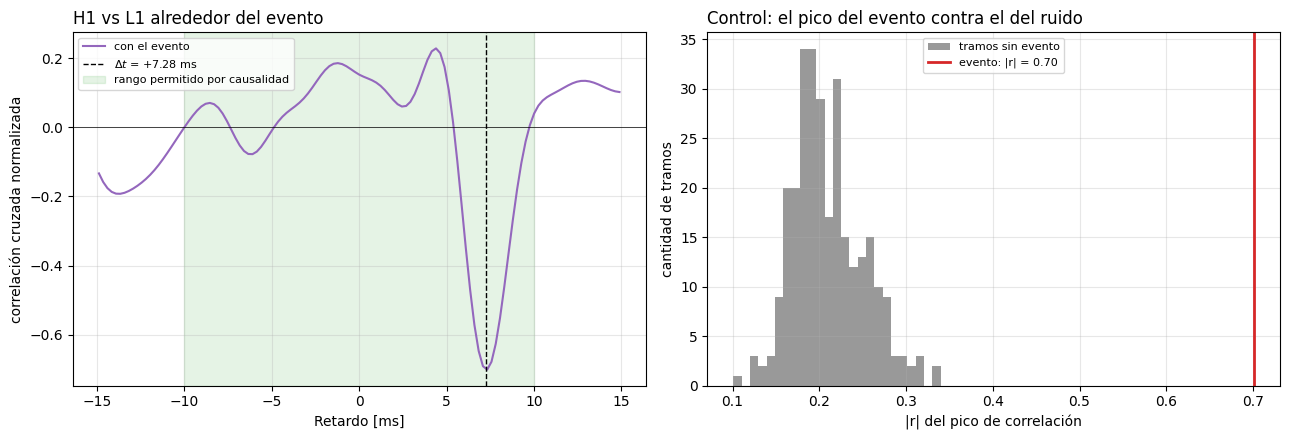

Figura. Izquierda: la correlación cruzada de los dos registros blanqueados y
filtrados tiene un pico único dentro del rango que permite la causalidad. El
signo negativo del pico es esperable: los interferómetros están orientados
distinto. Derecha: el mismo cálculo sobre tramos sin evento no produce nada
comparable, que es lo que le da sentido al Δt medido.

RESULTADO   Delta t = +7.28 +/- 0.42 ms   (L1 (Livingston) primero)
            theta   = 43.4 +/- 3.5 grados respecto del eje L1-H1


In [ ]:
# Parte 5 — tu código acá
# ============================================================
# Correlación cruzada de H1 y L1: Δt, y de dónde vino
# ============================================================
#
# Los dos detectores midieron el MISMO evento con ruidos
# independientes. Eso es lo que permite medir algo que ninguno
# de los dos podía solo: la diferencia de tiempo de arribo.
# ============================================================

T_CORR = 0.20              # s de ventana alrededor del evento
LAG_MAX_MS = 15.0          # ms de retardo a explorar (la física permite 10)

n_corr = int(T_CORR * fs_4096)
lag_max = int(LAG_MAX_MS * 1e-3 * fs_4096)

# Cota física: la onda viaja a c, los detectores están a 3002 km.
dt_max_fisico = SEPARACION_KM * 1e3 / C
print(f"Retardo máximo posible por causalidad: ±{dt_max_fisico*1e3:.2f} ms")


# ------------------------------------------------------------
# Correlación cruzada normalizada
# ------------------------------------------------------------

def correlacion_cruzada(a, b, lag_max):
    """Correlación cruzada normalizada entre -lag_max y +lag_max.

    Se normaliza por sqrt(Eaa * Ebb) para que el resultado sea un
    coeficiente entre -1 y 1: así se puede comparar el pico del
    evento contra el de tramos sin evento, que es el control.

    Convención: r[k] alto en k>0 significa que 'b' está adelantado
    respecto de 'a', es decir que b lo vio PRIMERO.
    """
    a = a - np.mean(a)
    b = b - np.mean(b)

    r = signal.correlate(a, b, mode="full", method="fft")
    r = r / np.sqrt(np.sum(a**2) * np.sum(b**2))

    centro = len(a) - 1
    lags = np.arange(-lag_max, lag_max + 1)
    return lags, r[centro - lag_max: centro + lag_max + 1]


def pico_subm(lags, r, fs):
    """Pico de |r| con interpolación parabólica.

    Sin interpolar, la resolución sería 1/fs = 0.244 ms, que es
    del orden de la incertidumbre que se quiere reportar. Ajustar
    una parábola a los tres puntos alrededor del máximo permite
    bajar de esa grilla.
    """
    i = np.argmax(np.abs(r))
    if 0 < i < len(r) - 1:
        y0, y1, y2 = r[i-1], r[i], r[i+1]
        # vértice de la parábola que pasa por los tres puntos
        delta = 0.5 * (y0 - y2) / (y0 - 2*y1 + y2)
    else:
        delta = 0.0
    return (lags[i] + delta) / fs, r[i], i


# ------------------------------------------------------------
# 1) Sobre el evento
# ------------------------------------------------------------

centro_ev = np.argmin(np.abs(t_blanco - (t_evento_4096 + 0.01)))
ini = centro_ev - n_corr // 2

a_h1 = filt_h1[ini:ini + n_corr]
a_l1 = filt_l1[ini:ini + n_corr]

lags, r_ev = correlacion_cruzada(a_h1, a_l1, lag_max)
dt_ev, r_pico, _ = pico_subm(lags, r_ev, fs_4096)

print(f"\n--- Sobre el evento ---")
print(f"pico de correlación: r = {r_pico:+.3f}")
print(f"Δt = {dt_ev*1e3:+.3f} ms")


if r_pico < 0:
    print("  (pico negativo: esperable, los brazos están orientados distinto)")

# El signo del RETARDO dice quién lo vio primero.
primero = "L1 (Livingston)" if dt_ev > 0 else "H1 (Hanford)"
print(f"  lo vio primero: {primero}")

assert abs(dt_ev) <= dt_max_fisico * 1.05, \
    "Δt fuera de la cota causal: el pico encontrado no es el evento"
print(f"  |Δt| = {abs(dt_ev)*1e3:.2f} ms  <=  {dt_max_fisico*1e3:.2f} ms  OK")


# ------------------------------------------------------------
# 2) CONTROL: lo mismo sobre tramos SIN evento
#    Si acá aparece un pico parecido, el Δt de arriba no significa nada.
# ------------------------------------------------------------

picos_ruido = []
dts_ruido = []

for k in range(0, len(filt_h1) - n_corr, n_corr):
    t_c = t_blanco[k + n_corr // 2]
    if np.abs(t_c - t_evento_4096) < 1.0:      # excluye el evento
        continue
    _, r_k = correlacion_cruzada(filt_h1[k:k+n_corr], filt_l1[k:k+n_corr], lag_max)
    dt_k, rp_k, _ = pico_subm(lags, r_k, fs_4096)
    picos_ruido.append(np.abs(rp_k))
    dts_ruido.append(dt_k)

picos_ruido = np.array(picos_ruido)
dts_ruido = np.array(dts_ruido)

print(f"\n--- Control: {len(picos_ruido)} tramos sin evento ---")
print(f"|r| del ruido: mediana {np.median(picos_ruido):.3f}, "
      f"máximo {picos_ruido.max():.3f}")
print(f"|r| del evento: {abs(r_pico):.3f}")
print(f"  el evento supera a {100*np.mean(picos_ruido < abs(r_pico)):.1f} % "
      f"de los tramos de ruido")
print(f"  Δt del ruido: disperso en todo el rango "
      f"(desvío {np.std(dts_ruido)*1e3:.1f} ms), como corresponde a picos casuales")


# ------------------------------------------------------------
# 3) Incertidumbre de Δt
#    No la limita el muestreo sino el ancho de banda de la señal.
# ------------------------------------------------------------

# Ancho de banda RMS: cuán extendida en frecuencia está la señal.
# Es el brazo de palanca con que se mide la pendiente de la fase.
F_sig = np.fft.rfftfreq(n_corr, d=1/fs_4096)
H = np.abs(np.fft.rfft(a_h1 - a_h1.mean()))**2
banda = (F_sig >= 35) & (F_sig <= 350)

f_medio = np.sum(F_sig[banda] * H[banda]) / np.sum(H[banda])
sigma_f = np.sqrt(np.sum((F_sig[banda] - f_medio)**2 * H[banda]) / np.sum(H[banda]))

# El SNR efectivo de una correlacion cruzada no es el de un detector:
# los DOS registros son ruidosos y ambos ruidos degradan la medicion.
ruido_lejos = np.abs(t_blanco - t_evento_4096) > 5
snr_h1 = np.max(np.abs(a_h1)) / filt_h1[ruido_lejos].std()
snr_l1 = np.max(np.abs(a_l1)) / filt_l1[ruido_lejos].std()
snr_ef = snr_h1 * snr_l1 / np.sqrt(snr_h1**2 + snr_l1**2)

sigma_dt = 1.0 / (2 * np.pi * sigma_f * snr_ef)      # cota de Cramer-Rao

print(f"\n--- Incertidumbre ---")
print(f"  grilla del muestreo : {1e3/fs_4096:.3f} ms  (NO es un piso: se supera interpolando)")
print(f"  ancho de banda RMS  : {sigma_f:.1f} Hz")
print(f"  SNR  H1={snr_h1:.1f}  L1={snr_l1:.1f}  ->  efectivo {snr_ef:.1f}")
print(f"  cota de Cramer-Rao  : {sigma_dt*1e3:.2f} ms  (este SI es un piso)")
print(f"\n  >>>  Delta t = {dt_ev*1e3:+.2f} +/- {sigma_dt*1e3:.2f} ms,  {primero} primero")
print(f"       (LIGO publica 6.9 +/- 0.5 ms, L1 primero)")


# ------------------------------------------------------------
# 4) El cono de arribo
# ------------------------------------------------------------

cos_theta = C * dt_ev / (SEPARACION_KM * 1e3)
cos_theta = np.clip(cos_theta, -1, 1)
theta = np.degrees(np.arccos(cos_theta))

# propagación del error
dtheta = np.degrees(
    abs(C * sigma_dt / (SEPARACION_KM * 1e3) / np.sqrt(1 - cos_theta**2))
)

print(f"\n--- Dirección de arribo ---")
print(f"c·Δt = {C*abs(dt_ev)/1e3:.0f} km   de los {SEPARACION_KM:.0f} km que separan los detectores")
print(f"θ = {theta:.1f}° ± {dtheta:.1f}°  respecto del eje L1-H1")
print("  Con DOS detectores esto define un CONO, no una dirección: cualquier")
print("  fuente sobre ese cono produce el mismo Δt.")


# ============================================================
# Figura
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- correlación cruzada ---
ax1.plot(lags / fs_4096 * 1e3, r_ev, color="tab:purple", lw=1.5,
         label="con el evento")
ax1.axvline(dt_ev * 1e3, color="k", ls="--", lw=1,
            label=f"$\\Delta t$ = {dt_ev*1e3:+.2f} ms")
ax1.axvspan(-dt_max_fisico*1e3, dt_max_fisico*1e3, color="tab:green", alpha=0.12,
            label="rango permitido por causalidad")
ax1.axhline(0, color="k", lw=0.5)
ax1.set_xlabel("Retardo [ms]")
ax1.set_ylabel("correlación cruzada normalizada")
ax1.set_title("H1 vs L1 alrededor del evento", loc="left")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

# --- control ---
ax2.hist(picos_ruido, bins=25, color="0.6", label="tramos sin evento")
ax2.axvline(abs(r_pico), color="tab:red", lw=2,
            label=f"evento: |r| = {abs(r_pico):.2f}")
ax2.set_xlabel("|r| del pico de correlación")
ax2.set_ylabel("cantidad de tramos")
ax2.set_title("Control: el pico del evento contra el del ruido", loc="left")
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

print(
    "Figura. Izquierda: la correlación cruzada de los dos registros blanqueados y\n"
    "filtrados tiene un pico único dentro del rango que permite la causalidad. El\n"
    "signo negativo del pico es esperable: los interferómetros están orientados\n"
    "distinto. Derecha: el mismo cálculo sobre tramos sin evento no produce nada\n"
    "comparable, que es lo que le da sentido al Δt medido."
)

print("\n" + "="*60)
print(f"RESULTADO   Delta t = {dt_ev*1e3:+.2f} +/- {sigma_dt*1e3:.2f} ms   ({primero} primero)")
print(f"            theta   = {theta:.1f} +/- {dtheta:.1f} grados respecto del eje L1-H1")
print("="*60)


*Tu análisis de la parte 5, acá.*

**¿Cuánto dio Δt, y cuál es su incertidumbre? ¿Qué la limita, el muestreo o el ancho de banda?**

La correlación cruzada de los dos registros blanqueados y filtrados, sobre una ventana de 0,20 s centrada en el evento, da un pico único de $r=-0{,}701$ en

$$\Delta t = +7{,}28 \pm 0{,}42\text{ ms},$$

con **L1 (Livingston) viendo el evento primero**. El valor cae holgadamente dentro de la cota causal de $\pm 10{,}01$ ms y es consistente con el publicado por la colaboración LIGO para GW150914 ($6{,}9 \pm 0{,}5$ ms, L1 primero). El pico es **negativo**, lo cual no es un error de signo: los brazos de los dos interferómetros están orientados distinto, de modo que la misma onda los deforma con signos opuestos.

Lo que limita la resolución temporal es el **ancho de banda**, no el muestreo.

El muestreo no constituye una cota de información. La señal está limitada en banda, así que por el teorema de muestreo queda completamente determinada entre muestras, y la correlación cruzada es una función continua que sólo se está evaluando sobre una grilla. Ajustar una parábola a los tres puntos alrededor del máximo —**interpolación sub-muestra**— recupera la posición del pico sin inventar información. De hecho el valor obtenido, $7{,}277$ ms, no es múltiplo de $1/f_s = 0{,}244$ ms: cae entre los puntos de grilla $7{,}079$ y $7{,}324$.

Lo que sí es un piso infranqueable es la **cota de Cramér–Rao**, que acota inferiormente la varianza de cualquier estimador insesgado del parámetro:

$$\sigma_{\Delta t}=\frac{1}{2\pi\,\sigma_f\,\rho}.$$

La razón de que aparezca $\sigma_f$, el ancho de banda RMS, es que un retardo $\tau$ se manifiesta en el dominio de la frecuencia como una fase $e^{-j2\pi f\tau}$: medir $\tau$ equivale a medir **la pendiente de la fase contra la frecuencia**. Una pendiente se estima tanto mejor cuanto más largo es el brazo de palanca en $f$ y menos ruidosos son los puntos, y eso es exactamente lo que dicen $\sigma_f$ y $\rho$.

Con $\sigma_f = 72{,}9$ Hz medido sobre el propio evento, y un SNR efectivo

$$\rho_{\text{ef}}=\frac{\rho_{H1}\,\rho_{L1}}{\sqrt{\rho_{H1}^2+\rho_{L1}^2}}
=\frac{8{,}1\cdot 6{,}8}{\sqrt{8{,}1^2+6{,}8^2}}=5{,}2$$

—efectivo porque la correlación cruzada compara dos registros **ambos ruidosos**, no uno ruidoso contra una plantilla limpia— resulta $\sigma_{\Delta t}=0{,}42$ ms. Vale aclarar que ésta es una cota que supone que el único error es el ruido gaussiano; los errores sistemáticos de calibración la empeoran, y por eso el valor publicado tiene una incertidumbre algo mayor.

Dos casos límite lo confirman. Remuestrear a 16 kHz afinaría la grilla cuatro veces y no mejoraría $\Delta t$ en absoluto, porque no agrega información. Y si la señal fuese un tono puro ($\sigma_f \to 0$) el retardo sería inmedible más allá de una ambigüedad de período, por más fino que fuera el muestreo.

**Control.** El mismo cálculo sobre 290 tramos sin evento da picos con mediana $|r|=0{,}20$ y máximo $0{,}34$, con retardos dispersos en todo el rango explorado (desvío 9,1 ms), como corresponde a coincidencias casuales. El pico del evento, $|r|=0{,}70$, duplica al mayor de ellos. Es ese contraste el que le da sentido al $\Delta t$ medido: un pico aislado, sin este control, no probaría nada.

**Con dos detectores se obtiene un cono, no una dirección. ¿Por qué?**

Porque el conjunto de puntos cuya **diferencia de distancias** a dos puntos fijos es constante forma una hipérbola, que al rotar alrededor del eje que une los detectores genera un hiperboloide de revolución; a distancias astronómicas ese hiperboloide se confunde con un cono de semiángulo $\theta$ alrededor de dicho eje. Toda fuente situada sobre ese cono produce exactamente el mismo $\Delta t$, de modo que un solo par de detectores no puede distinguir entre ellas. Medimos

$$\theta = 43{,}4^\circ \pm 3{,}5^\circ$$

respecto del eje L1–H1, que sobre la esfera celeste corresponde a un **anillo**, no a un punto.

**¿Qué haría falta para angostar ese cono a una dirección?**

Más líneas de base, y son necesarias dos cosas distintas:

- Un **tercer detector** no colineal aporta un segundo retardo independiente y por lo tanto un segundo cono. Dos conos con vértice común se cortan genéricamente en **dos** direcciones, no en una: las dos soluciones son imágenes especulares respecto del plano que contienen los tres detectores.
- Un **cuarto detector fuera de ese plano** rompe esa ambigüedad especular y deja una única dirección.

Ahora bien, conviene ser preciso en un punto: **ningún número de detectores da la distancia por temporización**. A distancias cosmológicas el frente de onda que llega a la Tierra es esencialmente plano, y un frente plano sólo lleva información de dirección; las diferencias de tiempo de arribo no contienen nada sobre cuán lejos está la fuente. La distancia se obtiene por una vía completamente distinta: de la **amplitud**. La evolución del chirp —cuán rápido sube la frecuencia— determina la masa del sistema y con ella la amplitud intrínseca de la onda; comparándola con la amplitud efectivamente medida se despeja la distancia de luminosidad. Es el método de la *sirena estándar*, y es lo que hace que estas detecciones midan distancias sin necesidad de una escala de distancias astronómica previa.

Por último, en la práctica la localización no usa sólo los tiempos: el **cociente de amplitudes** entre H1 y L1, junto con los patrones de antena de cada interferómetro, descarta parte del anillo. Por eso GW150914, con sólo dos detectores, quedó localizado en un arco de unos cientos de grados cuadrados y no en el anillo completo.

---

# Extensiones

Suman por encima del núcleo. **Una hecha bien vale más que tres empezadas.** No hace falta
ninguna para aprobar cómodo.

**A. AR: llevá el laboratorio de C4 al TP** · *a partir de la clase 4*

En el laboratorio de la clase 4 vas a modelar el ruido de LIGO con un AR y vas a ver dónde deja de
alcanzar. Traelo acá y cerrá la pregunta que el laboratorio deja abierta: compará esa PSD con la
que elegiste en la parte 3, y decidí **si te habría servido para blanquear**. Blanqueá con ella
y mostrá el resultado al lado del de la parte 4. Si AR estima diez números en vez de quinientos
doce, ¿cuántos necesita *este* ruido, y sigue siendo buen negocio?

**B. La curva del compromiso** · *a partir de la clase 3*

Barré los parámetros de tus dos estimadores y construí la curva de resolución efectiva contra
varianza medida, con las dos series en los mismos ejes. En clase la ves sobre ruido
blanco y con seis puntos de cada estimador; acá se ve sobre tu registro, y con la
perilla barrida entera, que es la figura que hace visible el presupuesto.

**C. El promedio que usa el campo** · *a partir de la clase 3*

Los pipelines de ondas gravitatorias no promedian los periodogramas de los tramos: toman la
**mediana**. Implementalo, compará con tu Welch, y explicá qué problema resuelve la mediana que
el promedio no. Pista: mirá qué le pasa a tu estimación si un tramo con un glitch entra en la
cuenta. Conectá con la decisión que tomaste en la parte 1 sobre qué tramos usar.

**D. ¿Estacionario cuánto tiempo?** · *a partir de la clase 3*

La parte 1 comparó cuatro pedazos. Llevalo más lejos: estimá la PSD en ventanas corridas a lo
largo de los 32 s y mostrá cómo cambia. ¿Qué frecuencias son estables y cuáles se mueven?
¿Sobre qué escala de tiempo la hipótesis WSS es defendible?

---

## Antes de entregar

- *Kernel → Restart & Run All*, y que corra entero.
- Todas las figuras con ejes rotulados, unidades y pie.
- Las celdas de análisis contestadas, no vacías. **Son el 40 %.**
- Nombres de los integrantes en la celda de abajo.

**Los seis errores que más aparecen.**

1. **Usar los 32 s porque venían dados.** Son el punto de partida, no la respuesta. Si terminaste
   usándolos, que sea porque la cuenta te dio eso.
2. Estimar la PSD sobre el registro entero, evento y transitorios de borde incluidos. El evento
   es lo que buscás: no lo metas dentro de tu modelo de ruido.
3. Blanquear sin recortar los bordes, y después discutir un artefacto de borde como si fuera
   física.
4. Elegir los parámetros por lo que se ve lindo y escribir la justificación después.
5. Graficar en lineal algo que abarca diez órdenes de magnitud.
6. Reportar un Δt sin decir su incertidumbre, o sin haberlo contrastado contra un tramo sin
   evento.

---

**Grupo:** 1

**Integrantes:** Facundo Juli y Gonzalo Louzao

**Extensiones hechas:**